# 1. Preprocessing
First step of our workflow is the preprocessing, a critical step that enables us to improve the quality of the data that we'll use to train and test our supervised and unsupervised models.
Raw sensor data contains noise, artifacts and chunks of data that are not significative for the evaluation of the final decision or that can distort model features and degrade downstream classification or analytical performance.


The primary objectives of preprocessing in this pipeline are to:
- **Improve Signal-to-Noise Ratio (SNR):** Filter out high-frequency noise and low-frequency motion artifacts.
- **Ensure Data Consistency:** Standardize sensor orientation across disparate measurements so feature extraction remains invariant to phone placement.
- **Isolate Target Behaviors:** Remove non-informative segments (e.g., stationarity or setup interactions) and segment continuous signals into uniform, labeled observation windows suitable for model training.

---

### Preprocessing Pipeline
1) **Platform Standardization**: as the representation (axis orientation) of the sensor logger app differ from Android and IOS devices and as data is recorded with different phones (that can be both Android and IOS), an axis standardization script is needed. The script turns every recording into a standardized recording as if all phones are operating on IOS;

2) **Edge Trimming**: cut out the first and last 1.5s from the recordings as the sensor's samples recorded in those timespans are influenced by the user touching the screen to hit the start/end recording button;

3) **Stationary Segment Removal**: During cycling it could happen that the user stops for a few seconds. This results in data that can't actually be labeled or can confuse the models in the final decision. Because of this we cut out stationary samples from the recordings;

4) **Gravity-Based Axis Alignment**: As the recordings can be done onto different bikes, and with different phone-support orientation, an axis allignment algorithm based on the gravity vector is performed. By running the script we can simulate consistent phone orientation for each measurment;

5) **Bandpass Filtering**: We apply a band pass filter in order to keep only the interesting frequencies (the ones in which bumpy roads and smooth roads differ the most) and remove noise.

6) **Windowing & Labeling**: Division of each recording into windows and labelling of them (while discarding windows containing a cut-out due to stationary recording as they can pollute the subsequent analysis);

In [198]:

# Initialization of the directories and files used in the preprocessing step.

import os
import pandas as pd
import numpy as np

RAW_REC_DIR = "../raw_data"
PRE_PROCESSING_DIR = "../preprocessing"

if not os.path.exists(PRE_PROCESSING_DIR):
    os.mkdir(PRE_PROCESSING_DIR)

CUT_OUT_BORDERS_DIR = PRE_PROCESSING_DIR + "/cut_out_start_end"
SENSOR_FILES = ["Accelerometer.csv", "Gyroscope.csv", "Gravity.csv"]


## Platform Standardization

The three sensors measure in the phone's own axes which are determined by the operating system of the phone itself.
Here we can see how axis orientation differ from one operating system to the other:

![Axis orientation](../images/axis_orientation.png)



### Reference frame

The reference is the phone fixed on the straight part of the handlebar, upright, perpendicular to the road, with the screen facing the rider.
We are going to call the **global reference system** as **bike system**.

| Axis | Physical direction in the reference position |
| --- | --- |
| x | along the handlebar, positive towards the rider's left |
| y | perpendicular to the road, positive downwards |
| z | horizontal, positive towards the travel direction |

In [199]:

# "Standardise Units & Frames" (Sensor Logger setting) converts iOS data to the
# Android convention.
# FALLBACKS, used only when Metadata.csv does not provide the information.
IOS_STANDARDISED = False   # fallback: True if iOS recordings had the setting ON
DEFAULT_PLATFORM = None    # fallback: "ios", "android" or None (= infer from data)

SENSORS = ["Accelerometer", "Gyroscope", "Gravity"]

# iOS and Android report Accelerometer and Gravity with opposite signs
# (iOS: inertial-force convention, gravity points down; Android: applied-force
# convention, gravity points up). The Gyroscope uses the same sign on both.
SIGN_FLIPPED_SENSORS = {"Accelerometer", "Gravity"}

def read_metadata(recording_path: str):
    """
    Reads Metadata.csv of one recording and returns (platform, standardised):
      platform     -> "ios", "android" or None            (column "platform")
      standardised -> True / False, or None if missing     (column containing
                      "standardisation"; None also if the value is unreadable)
    """
    for name in ("Metadata.csv", "metadata.csv"):
        path = os.path.join(recording_path, name)
        if not os.path.exists(path):
            continue
        meta = pd.read_csv(path)
        if meta.empty:
            return None, None
        # Column names are matched case-insensitively
        cols = {c.strip().lower(): c for c in meta.columns}

        platform = None
        if "platform" in cols:
            value = str(meta[cols["platform"]].iloc[0]).strip().lower()
            platform = "ios" if "ios" in value else "android" if "android" in value else None

        standardised = None
        std_cols = [c for key, c in cols.items() if "standardisation" in key]
        if std_cols:
            value = str(meta[std_cols[0]].iloc[0]).strip().lower()
            if value == "true":
                standardised = True
            elif value == "false":
                standardised = False
            else:
                print(f"  Warning: unreadable value '{value}' in column '{std_cols[0]}' of {name}.")
        return platform, standardised
    return None, None


def to_ios_sign(platform, standardised, grav_raw: np.ndarray):
    """
    Standardize sign convention.
    Returns (sign, source):
      sign   -> multiplier for Accelerometer and Gravity:
                +1 = data already in iOS convention, -1 = data in Android convention
      source -> where the decision came from (printed and stored in the summary)
    """
    if platform is None and DEFAULT_PLATFORM is not None:
        platform = DEFAULT_PLATFORM

    # Android is always in Android convention (the setting only affects iOS)
    if platform == "android":
        return -1.0, "platform=android"

    # iOS: raw data are in iOS convention, unless "Standardise Units & Frames" was ON
    if platform == "ios":
        if standardised is not None:
            return (-1.0 if standardised else 1.0), f"metadata standardised={standardised}"
        return (-1.0 if IOS_STANDARDISED else 1.0), f"config IOS_STANDARDISED={IOS_STANDARDISED}"

    # Unknown platform: a handlebar mount never holds the phone upside down, so in
    # iOS convention the y component of gravity must be negative. Use that to decide.
    return (1.0 if np.median(grav_raw[:, 1]) < 0 else -1.0), "inferred from gravity sign"




# MAIN LOOP: --------------------------------------------------------------


for recording in sorted(os.listdir(RAW_REC_DIR)):

    print(f"Processing {recording} ...")    
    recording_path = os.path.join(RAW_REC_DIR, recording)
    if not os.path.isdir(recording_path):
        continue

    gravity_path = os.path.join(recording_path, "Gravity.csv")
    if not os.path.exists(gravity_path):
        print(f"Warning: No Gravity.csv found for {recording}. Skipping.")
        continue

    # --- STEP 1: sign convention -> iOS --------------------------------------
    grav_raw = pd.read_csv(gravity_path)[["x", "y", "z"]].to_numpy()
    platform, standardised = read_metadata(recording_path)
    sign, sign_source = to_ios_sign(platform, standardised, grav_raw)
    grav = sign * grav_raw
    pd.DataFrame(grav, columns=["x", "y", "z"]).to_csv(os.path.join(recording_path, "Gravity_sign_corrected.csv"), index=False)


    for sensor_type in SENSORS:
        sensor_path = os.path.join(recording_path, f"{sensor_type}.csv")
        if not os.path.exists(sensor_path):
            continue
        s = sign if sensor_type in SIGN_FLIPPED_SENSORS else 1.0   # gyroscope is never flipped
        aligned_m = pd.read_csv(sensor_path)[["x", "y", "z"]].to_numpy() * s
        pd.DataFrame(aligned_m, columns=["x", "y", "z"]).to_csv(os.path.join(recording_path, f"{sensor_type}_sign_corrected.csv"), index=False)




Processing bumpy_Campus-2026-10-03_18-33-15 ...
Processing bumpy_casa-2026-10-04_10-31-51 ...
Processing bumpy_con_tante_buche-2026-09-21_13-24-26 ...
Processing bumpy_con_una_grande_curva_alla_fine-2026-09-21_13-47-25 ...
Processing bumpy_mattonelle_dentro_al_campus-2026-10-04_08-49-32 ...
Processing bumpy_park-2026-10-04_11-55-42 ...
Processing bumpy_stadio ...
Processing bumpy_stadio_veloce-2026-10-04_08-44-03 ...
Processing bumpy_station-2026-10-04_10-33-25 ...
Processing bumpy_station2-2026-10-04_11-51-56 ...
Processing bumpy_stazione ...
Processing bumpy_stradabumpy_con_rialzi_e_buche-2026-09-21_13-44-51 ...
Processing bumpy_swapfiets ...
Processing smooth_con_fermata-2026-09-23_14-28-20 ...
Processing smooth_con_fermata_2-2026-09-23_14-35-33 ...
Processing smooth_con_un_po_di_rialzi_e_piccoli_tratti_saltellanti-2026-09-21_13-33-45 ...
Processing smooth_entrata_campus-2026-10-04_08-48-01 ...
Processing smooth_grande_curva_apl_inizio-2026-09-21_13-20-05 ...
Processing smooth_lidl-

## Edge Trimming

We delete the first and last 1.5s timespans as they're influenced by the rider touching the screen to hit the record button.

In [200]:
# Cut-Out script
# Read recordings in each folder and cut the first and last 1.5 seconds meausurements

for recording in os.listdir(RAW_REC_DIR):

    #print(f"Processing {recording}...")
    recording_path = os.path.join(RAW_REC_DIR, recording)
    cutout_recording_path = os.path.join(CUT_OUT_BORDERS_DIR, recording)

    if not os.path.exists(cutout_recording_path):
        os.makedirs(cutout_recording_path)

    for measurement_type in os.listdir(recording_path):

        if measurement_type in SENSOR_FILES:

            raw_file_path = os.path.join(recording_path, measurement_type)
            cutout_file_path = os.path.join(cutout_recording_path, measurement_type)

            # Read the CSV file with pandas

            # pd.read_csv() loads the CSV into a Pandas DataFrame:
            # a tabular structure (map or dictionary) where each column contains an array of values
            # associated with a common row index.
            data = pd.read_csv(raw_file_path)

            # Cut the first and last 1.5 seconds of measurements
            sampling_rate = 100  # Assuming a sampling rate of 100 Hz
            cut_samples = int(1.5 * sampling_rate)

            # Ensure we have enough data to cut
            if len(data) > 2 * cut_samples:
                # iloc selects rows by integer position, excluding the first and last cut_samples rows.
                cut_data = data.iloc[cut_samples:-cut_samples]
                #index=False tells pandas not to save the DataFrame’s row index as an extra column in the CSV file.
                cut_data.to_csv(cutout_file_path, index=False)
                print(f"Processed {recording}: Cut first and last 1.5 seconds.")
            else:
                print(f"Skipping {recording}: Not enough data to cut.")



Processed bumpy_Campus-2026-10-03_18-33-15: Cut first and last 1.5 seconds.
Processed bumpy_Campus-2026-10-03_18-33-15: Cut first and last 1.5 seconds.
Processed bumpy_Campus-2026-10-03_18-33-15: Cut first and last 1.5 seconds.
Processed bumpy_casa-2026-10-04_10-31-51: Cut first and last 1.5 seconds.
Processed bumpy_casa-2026-10-04_10-31-51: Cut first and last 1.5 seconds.
Processed bumpy_casa-2026-10-04_10-31-51: Cut first and last 1.5 seconds.
Processed bumpy_con_tante_buche-2026-09-21_13-24-26: Cut first and last 1.5 seconds.
Processed bumpy_con_tante_buche-2026-09-21_13-24-26: Cut first and last 1.5 seconds.
Processed bumpy_con_tante_buche-2026-09-21_13-24-26: Cut first and last 1.5 seconds.
Processed bumpy_con_una_grande_curva_alla_fine-2026-09-21_13-47-25: Cut first and last 1.5 seconds.
Processed bumpy_con_una_grande_curva_alla_fine-2026-09-21_13-47-25: Cut first and last 1.5 seconds.
Processed bumpy_con_una_grande_curva_alla_fine-2026-09-21_13-47-25: Cut first and last 1.5 seco

### Plotting of the cut out measurments
In order to check if the cut out was done properly we plot one of the resulting modified recordings. 

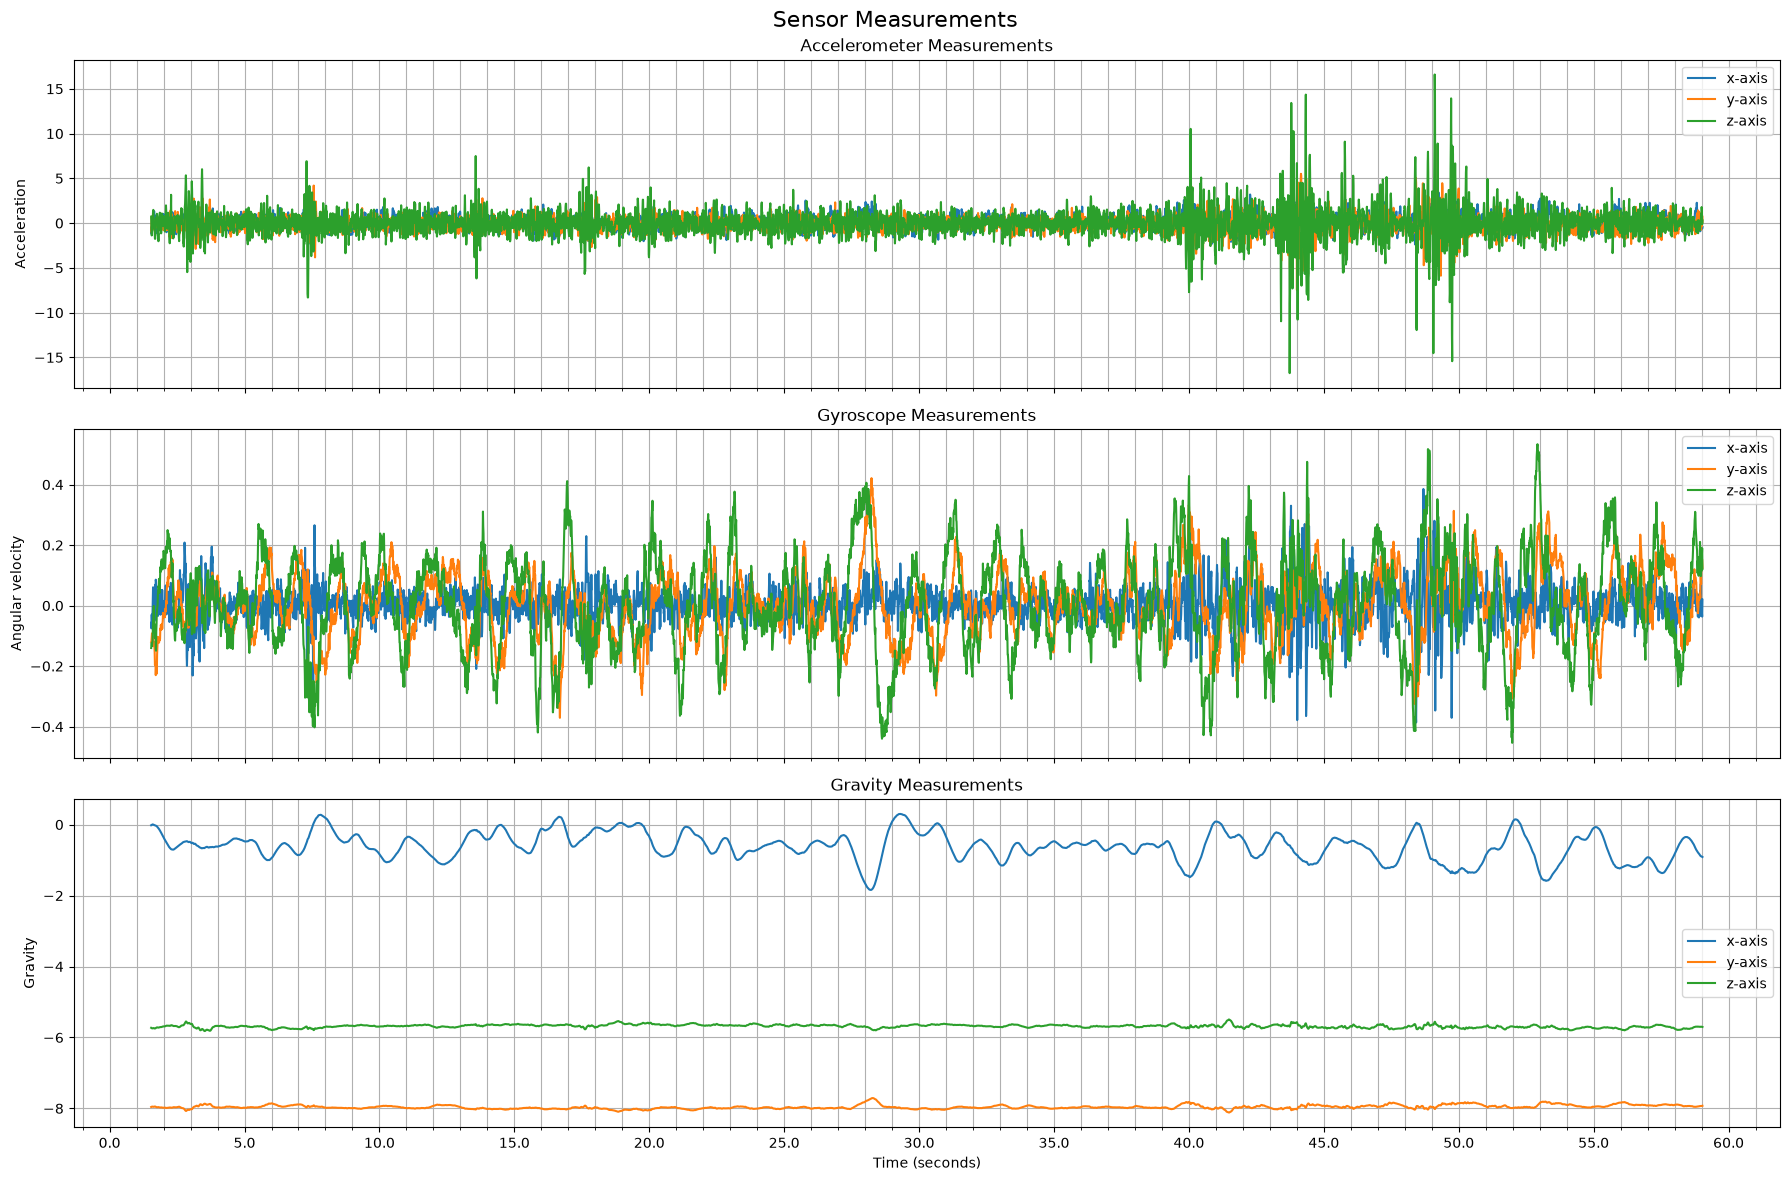

In [201]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, FormatStrFormatter

PRE_PROCESSING_DIR = "../preprocessing"
CUT_OUT_DIR = f"{PRE_PROCESSING_DIR}/cut_out_start_end"

ACCELEROMETER_DIR = f"{CUT_OUT_DIR}/bumpy_stadio"

AXES = ["x", "y", "z"]

def configure_axis(ax, title, ylabel):
    """Configure a plot axis with common formatting."""
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.grid(True, which="both")

    ax.xaxis.set_major_locator(MultipleLocator(5.0))
    ax.xaxis.set_major_formatter(FormatStrFormatter("%.1f"))
    ax.xaxis.set_minor_locator(MultipleLocator(1.0))

    ax.legend()


def plot_measurement(ax, data, title, ylabel):
    """Plot x, y and z axes of a sensor measurement on the same graph."""
    for axis_name in AXES:
        ax.plot(
            data["seconds_elapsed"],
            data[axis_name],
            label=f"{axis_name}-axis"
        )

    configure_axis(ax, title, ylabel)

# Load data ---------------------------------------------------------

accelerometer = pd.read_csv(
    f"{ACCELEROMETER_DIR}/Accelerometer.csv"
)

gyroscope = pd.read_csv(
    f"{ACCELEROMETER_DIR}/Gyroscope.csv"
)

gravity = pd.read_csv(
    f"{ACCELEROMETER_DIR}/Gravity.csv"
)


# Plot ----------------------------------------------------------------

fig, axes = plt.subplots(
    3,
    1,
    figsize=(18, 12),
    sharex=True
)

plot_measurement(
    axes[0],
    accelerometer,
    "Accelerometer Measurements",
    "Acceleration"
)

plot_measurement(
    axes[1],
    gyroscope,
    "Gyroscope Measurements",
    "Angular velocity"
)

plot_measurement(
    axes[2],
    gravity,
    "Gravity Measurements",
    "Gravity"
)

axes[-1].set_xlabel("Time (seconds)")

fig.suptitle(
    "Sensor Measurements",
    fontsize=16
)

fig.tight_layout()

plt.show()


> As we can see the cut was performed the right way, the recordings don't show any data before the 1.5s time mark and in the last 1.5 seconds

## Stationary Segment Removal

We remove stationary segments from the recordings to prevent them from influencing the model performance. During these stationary segments, sensor measurements lack the dynamic variations necessary to distinguish between bumpy and smooth bike lanes surfaces.

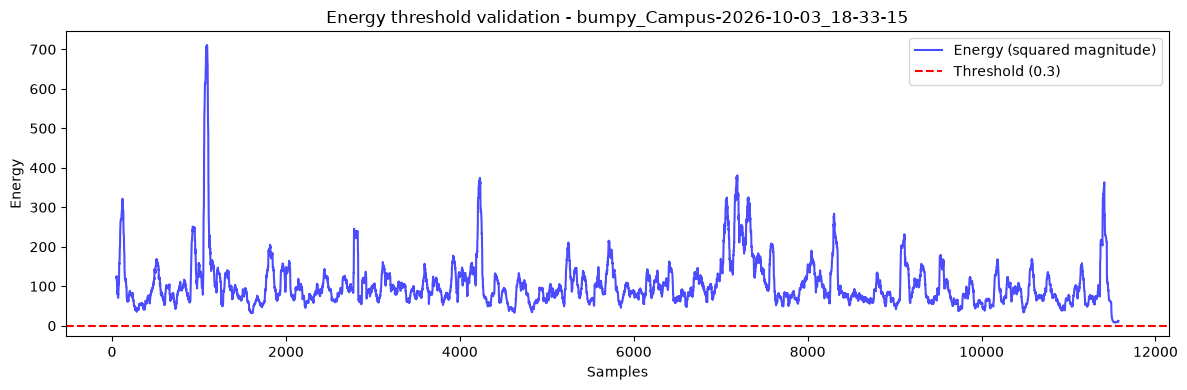

In [202]:
# stationary segment removal script
import pandas as pd
import os
import matplotlib.pyplot as plt

OUTPUT_DIR = "../preprocessing/cut_out_remove_stationary"

VALIDATE_PLOT = True  # Set to True to visualize the energy and threshold for validation

#for each recording, remove the stationary segments based on the accelerometer data
for recording in os.listdir(CUT_OUT_DIR):
    accelerometer_file_path = os.path.join(CUT_OUT_DIR, recording, "Accelerometer.csv")
    accelerometer_data = pd.read_csv(accelerometer_file_path)
    gyroscope_file_path = os.path.join(CUT_OUT_DIR, recording, "Gyroscope.csv")
    gyroscope_data = pd.read_csv(gyroscope_file_path)
    gravity_file_path = os.path.join(CUT_OUT_DIR, recording, "Gravity.csv")
    gravity_data = pd.read_csv(gravity_file_path)

    MAX_ALLOWED_DIFF = 5  # Allow up to 5 samples of difference

    # TODO it should be always the same
    lengths = {
        'Acc': len(accelerometer_data),
        'Gyro': len(gyroscope_data),
        'Grav': len(gravity_data)
    }
    
    max_len = max(lengths.values())
    min_len = min(lengths.values())
    
    # Raise error only if the difference is actually problematic
    if (max_len - min_len) > MAX_ALLOWED_DIFF:
        raise ValueError(f"CRITICAL ERROR in {recording}: Sensors are out of sync! "
                         f"Difference is {max_len - min_len} (max allowed: {MAX_ALLOWED_DIFF}). "
                         f"Lengths: {lengths}")
    
    # Truncate all DataFrames to the shortest length to ensure perfect alignment (by creating copies of the DataFrames)
    acc_work= accelerometer_data.iloc[:min_len]
    gyr_work = gyroscope_data.iloc[:min_len]
    grav_work = gravity_data.iloc[:min_len]

    # Calculate the magnitude of the accelerometer data
    magnitude_vec = (acc_work["x"]**2 + acc_work["y"]**2 + acc_work["z"]**2)**0.5
    energy_threshold = 0.30  # Define a threshold for stationary segments

    # Calculate the energy of the accelerometer data using rolling window mean of the squared magnitude
    energy = (magnitude_vec**2).rolling(window=50).mean()  # Adjust window size as needed

    # Plot the energy and threshold for validation
    if VALIDATE_PLOT:
        plt.figure(figsize=(12, 4))
        plt.plot(energy, label='Energy (squared magnitude)', color='blue', alpha=0.7)
        plt.axhline(y=energy_threshold, color='red', linestyle='--', label=f'Threshold ({energy_threshold})')
        plt.title(f"Energy threshold validation - {recording}")
        plt.xlabel("Samples")
        plt.ylabel("Energy")
        plt.legend()
        plt.tight_layout()
        plt.show()
        
        VALIDATE_PLOT = False

    # Identify stationary segments where energy is below the threshold
    stationary_segments = energy < energy_threshold

    # require that stationary segments are at least 2 seconds long (200 samples at 100 Hz)
    min_stationary_length = 200

    # Runs are windows of datapoints in which either the energy is higher than the treshold or lower of it

    # 1. assign a unique ID to each run of consecutive True values in stationary_segments
    run_ids = (stationary_segments != stationary_segments.shift()).cumsum()
    
    # 2. compute the length of each run of consecutive True values
    run_lengths = stationary_segments.groupby(run_ids).transform('size')
    
    # 3. keep only the runs of consecutive True values that are at least min_stationary_length long
    stationary_segments = stationary_segments & (run_lengths >= min_stationary_length)

    # Remove stationary segments from the all data
    filtered_accelerometer_data = acc_work[~stationary_segments]
    filtered_gyroscope_data = gyr_work[~stationary_segments]
    filtered_gravity_data = grav_work[~stationary_segments]
    
    # create a new folder in preprocessing called cut_out_remove_stationary to store the filtered accelerometer data
    new_folder_path = os.path.join(OUTPUT_DIR, recording)
    os.makedirs(new_folder_path, exist_ok=True)

    # Save the filtered data
    filtered_accelerometer_data.to_csv(os.path.join(new_folder_path, "Accelerometer.csv"), index=False)
    filtered_gyroscope_data.to_csv(os.path.join(new_folder_path, "Gyroscope.csv"), index=False)
    filtered_gravity_data.to_csv(os.path.join(new_folder_path, "Gravity.csv"), index=False)

### Check on a recording with a stationary segment to see if any part was removed
In order to check if the cut out was done properly we plot one of the recordings that we know has a stationary segment in it. 

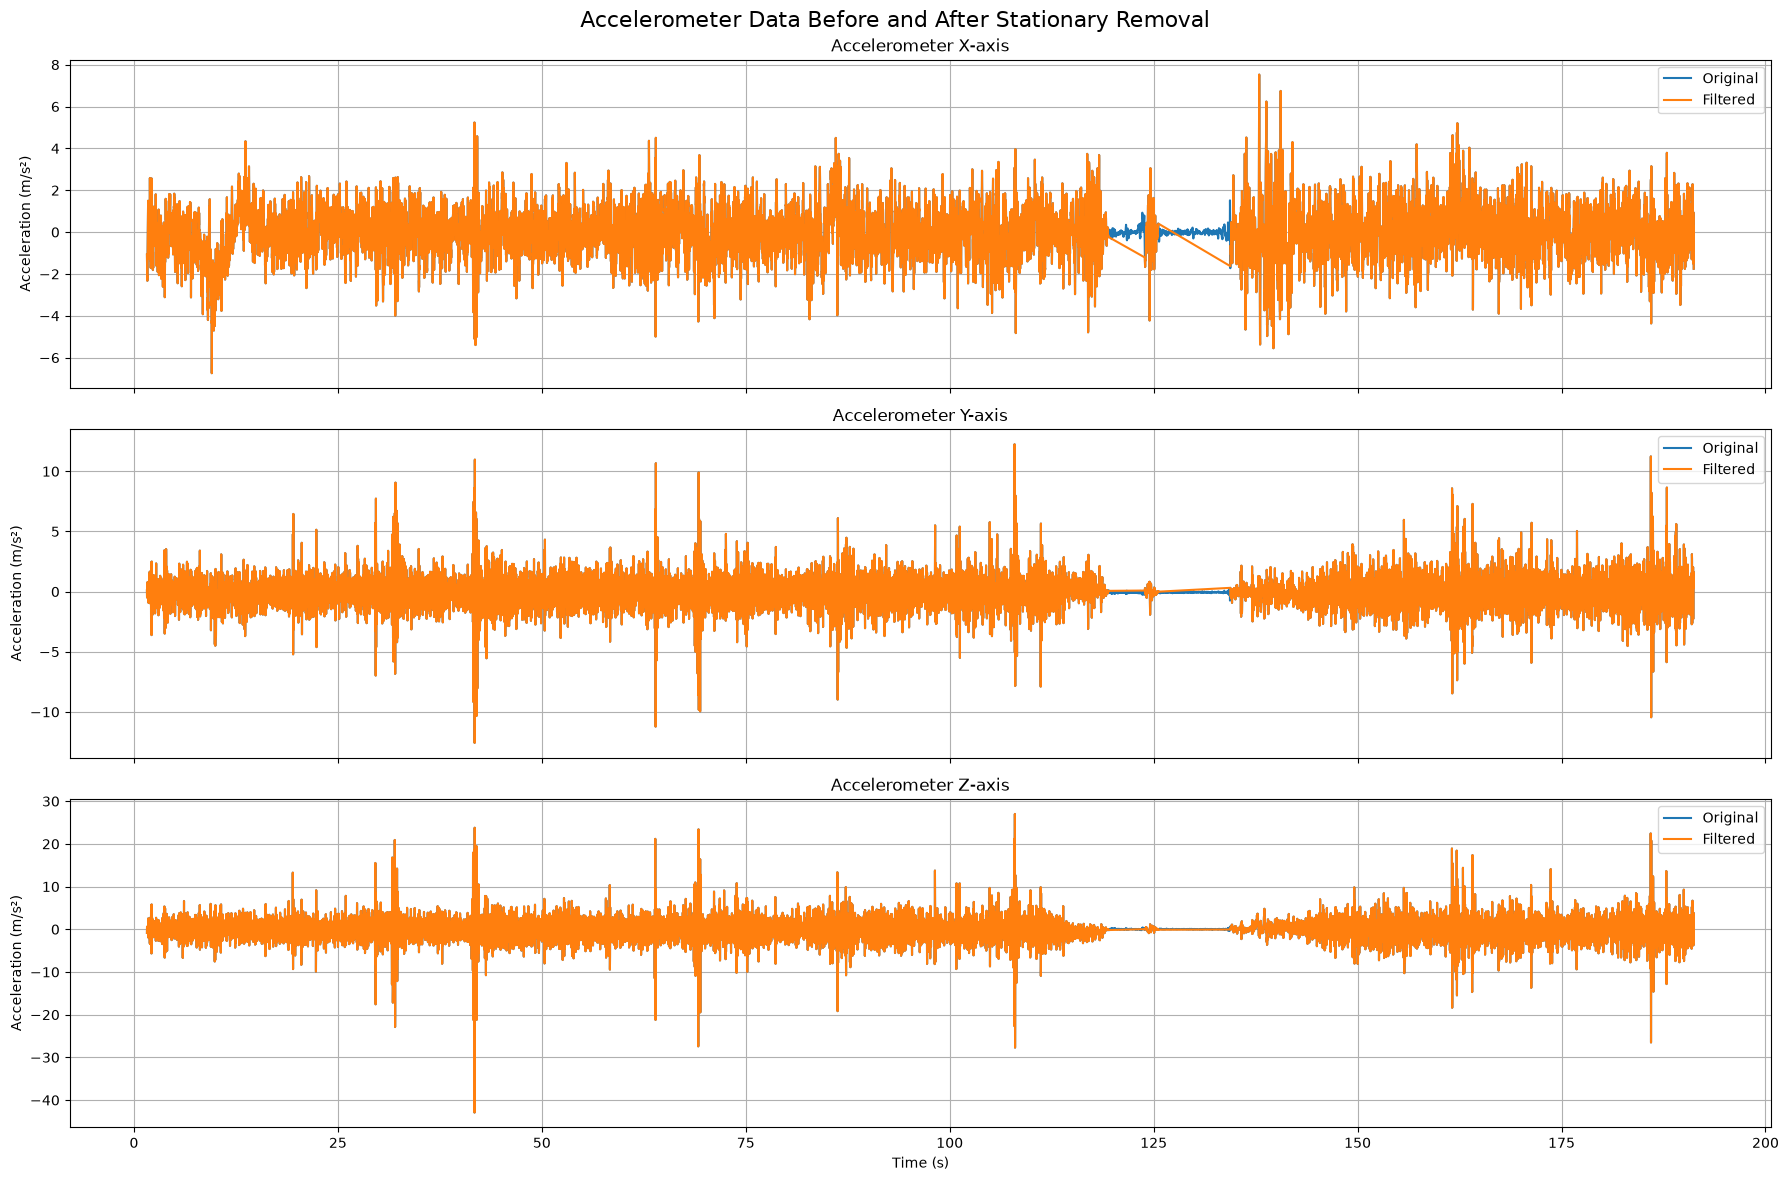

In [203]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# load data
recording = "smooth_con_fermata-2026-09-23_14-28-20" # Example with an actual stationary segment

original_accelerometer_data = pd.read_csv(
    os.path.join(CUT_OUT_DIR, recording, "Accelerometer.csv")
)

filtered_accelerometer_data = pd.read_csv(
    os.path.join(OUTPUT_DIR, recording, "Accelerometer.csv")
)

axes_names = ["x", "y", "z"]

fig, axes = plt.subplots(
    3,
    1,
    figsize=(18, 12),
    sharex=True
)

# Plot each axis comparing original with filtered one
for ax, axis_name in zip(axes, axes_names):

    # Original data
    ax.plot(
        original_accelerometer_data["seconds_elapsed"],
        original_accelerometer_data[axis_name],
        label="Original"
    )

    # Filtered data
    ax.plot(
        filtered_accelerometer_data["seconds_elapsed"],
        filtered_accelerometer_data[axis_name],
        label="Filtered"
    )

    ax.set_title(f"Accelerometer {axis_name.upper()}-axis")
    ax.set_ylabel("Acceleration (m/s²)")
    ax.grid(True, which="both")
    ax.legend()


axes[-1].set_xlabel("Time (s)")

fig.suptitle(
    "Accelerometer Data Before and After Stationary Removal",
    fontsize=16
)

fig.tight_layout()
plt.show()


As we can see, the filtering of the recording "smooth_con_fermata-2026-09-23_14-28-20" was performed correctly, removing the data recorded during the stationary periods. 

>In the filtered plots, this is highlighted by the straight lines connecting the end of one movement segment to the beginning of the next, indicating that the data points corresponding to the stationary periods have been removed.

### Sensor Axis Alignment Pipeline

This algorithm normalizes the sensor data by rotating the raw smartphone reference frame into a standardized, bike-fixed reference frame. In the aligned target system, the **X-axis** points left along the handlebar, the **Y-axis** points vertically downward, and the **Z-axis** points forward in the direction of travel.

To do so we follow these steps:

1. **Gravity Vector Estimation:** we compute the component-wise median gravity vector ($\mathbf{g}_{\text{med}}$) over the entire recording. Using the robust median isolates the static gravity component by filtering out dynamic accelerations caused by road bumps, turns, braking, and phone vibration;
2. **Physical Mount Kinematics Decomposition ($Z \rightarrow X$):** Rather than applying an arbitrary minimal rotation (such as Rodrigues' rotation), the algorithm decomposes orientation offset into two real physical hinges corresponding to the phone mount structure:
   - **Roll ($\psi$, around Z-axis):** Undoes the rotation of the phone inside the holder;
   - **Pitch ($\theta$, around X-axis):** Undoes the tilt angle of the mount around the handlebar.
   
   Combining these sequentially builds a single transformation matrix $\mathbf{R} = \mathbf{R}_x(\theta) \mathbf{R}_z(\psi)$ that aligns $\mathbf{g}_{\text{med}}$ precisely with the downward target vector $(0, -1, 0)$;
3. **Batch Transformation & Verification:** we apply the resulting static rotation matrix $\mathbf{R}$ across all samples for each sensor stream ($\mathbf{v}' = \mathbf{R} \mathbf{v}$). The pipeline includes automated diagnostic checks for sensor scale errors, mechanical mount slippage over time (gravity drift), extreme pitch angles, and residual alignment accuracy.

> **Note on Yaw & Slope:** Unconstrained rotations around the vertical axis (yaw) are intentionally left uncorrected as gravity cannot observe them without absolute data like GPS. Handlebar steering dynamics remain in the signal as true bicycle motion, while road slope introduces only a negligible constant offset on pitch.

<br>

# THIS CELL NEEDS TO BE REMOVED AFTER CHECKING IF EVERYTHING IS ON POINT WITH THE ABOVE ONE

## Gravity-Based Axis Alignment

As the data was gathered on different bikes with the same support but not with consistent tilt of it we need to modify the data as if it was gathered with the same consistent setup.

<br>
<br>

### General Assumptions:

<br>

#### Assumption 0: project setup

- **Phone Setup:** Sensor Logger recordings of bike rides, with the phone fixed on the straight part of the handlebar in a stable condition.
- **Input data:** Accelerometer and Gravity in m/s², Gyroscope in rad/s, columns x, y, z in the phone's axes.
- **Variable mounting:** the **roll angle**, and the **pitch angle** of the holder changes from one recording to another, so the same bike motion ends up on different axes.
- **Different operating systems:** iOS and Android report Accelerometer and Gravity with opposite signs, while the Gyroscope has the same sign.

Goal: express all measurements in one **global reference frame**, identical for every recording and every phone.

<br>

#### Assumption 1: yaw angle neglected

Yaw is not estimated: gravity cannot measure it, and GPS, which would be needed to estimate it, is not among the data.

- **Why gravity is not enough:** gravity is a vertical reference. It fixes two of the three angles (pitch and roll); a rotation around the vertical leaves it unchanged.
- **What would be needed:** a horizontal reference, for example the direction of travel or the speed change from GPS, to compare with the accelerations when braking and starting.
- **Assumption adopted:** the phone is fixed on the straight part of the handlebar with the screen facing the rider, so the holder's yaw is zero. The "Z then X" decomposition implements exactly this assumption. A ball-joint holder twisted around the vertical would introduce a real yaw that cannot be detected.
- **Steering:** the handlebar rotates relative to the frame around the steering axis, typically tilted about 18° from the vertical. The rotation is almost entirely yaw and gravity sees only about 30% of it (sin 18°), so it cannot be corrected with gravity. It would require the steering angle at every instant, from a second sensor on the frame or from GPS with a kinematic model.
- **Consequence:** the aligned frame is the handlebar frame and coincides with the bike frame when riding straight. With a steering angle δ, a fraction sin δ of the longitudinal acceleration moves to the lateral axis.
- **Magnitude:** at normal speeds δ is a few degrees; in a curve with a 20 m radius it is about 3° (a 6% fraction). Large values occur only at low speed and when manoeuvring. Steering stays in the data as bike motion, for example on Gyroscope y in curves.

<br>

#### Assumption 2: road slope

Road slope is not corrected: without GPS or a barometer it cannot be measured, and the median reduces it to a small constant error on pitch only.

- **Why it is a problem:** gravity measures orientation relative to the vertical, while the reference frame is defined relative to the road. On a slope α, a phone tilted by θ relative to the bike is tilted by θ ± α relative to the vertical: both rotations happen around the same axis, so the angles add. With the typical mount: θ − α uphill, θ + α downhill.
- **What the median does:** it does not remove the slope, it reduces it to a constant error equal to the typical slope of the recording. On flat routes, or routes with both climbs and descents, it cancels out and is close to 0.
- **Worst case:** a constant 5% climb gives a 2.9° error on θ, i.e. about 5% of the vertical component on the longitudinal axis.
- **Only θ, not ψ:** the slope rotates around the same axis as the pitch, so it does not affect the estimate of the phone's rotation inside the holder.
- **Why not sample by sample:** it would not remove the slope; it would introduce it at every instant, together with leaning in curves, braking and fusion errors. With 20° of lean in a curve, 34% of the vertical signal would end up on the lateral axis.
- **Possible check without GPS:** if the same route is recorded in both directions, the difference between the two θ values is about twice the mean slope.


<br>

---

<br>


### Reference frame

The reference is the phone fixed on the straight part of the handlebar, upright, perpendicular to the road, with the screen facing the rider.
We are going to call the **global reference system** as **bike system**.

| Axis | Physical direction in the reference position |
| --- | --- |
| x | along the handlebar, positive towards the rider's left |
| y | perpendicular to the road, positive downwards |
| z | horizontal, positive towards the travel direction |

The axes are right-handed and coincide with the phone's physical axes, which are the same on iOS and Android. The frame is attached to the handlebar: uphill, y stays perpendicular to the road; in a curve, it leans with the bike.

**Positive direction: iOS convention.** On iOS, Accelerometer and Gravity follow the inertial-force convention, so the Gravity vector points towards the ground. Android uses the opposite sign, the applied-force convention. The Gyroscope uses the same convention on both: positive rotation is counter-clockwise around the axis (right-hand rule).


**Units:** m/s² for Accelerometer and Gravity, rad/s for Gyroscope, on both operating systems.

How to read the aligned data:

| Situation | Expected value |
| --- | --- |
| Bike at rest on flat ground | Gravity ≈ (0, −9.81, 0) m/s² |
| Braking | Accelerometer z < 0 |
| Accelerating forward | Accelerometer z > 0 |
| Left turn | Gyroscope y > 0 |


<br>

---

<br>

### Method

For each recording a single rotation R, constant in time, is computed and applied to every sample of the three sensors.

1. **Median gravity vector.** g_med is the component-wise median of Gravity over the whole recording. The holder is fixed, so the pitch to correct is a constant. Instant gravity also changes with steering, leaning in curves, bumps, braking and sensor-fusion errors: the median is not affected, as long as most of the ride is on straight road.


2. **"Z then X" decomposition.** The holder has two degrees of freedom: the phone can be rolled inside the holder by an angle ψ around z, and the holder pitched by an angle θ around the handlebar, i.e. around x. From the upward unit vector u = −g_med / |g_med| the two angles and the rotation are derived (formulas below).

3. **Application.** The same R is applied to Accelerometer, Gyroscope and Gravity, after the sign change of step 1: v' = R · (s · v), with s = ±1 only for Accelerometer and Gravity. With samples stored as rows: X' = (s · X) · Rᵀ.

Components of u in the phone's axes, as a function of the mounting:

<br>
$$
\newline
\theta = pitch angle,  \psi= roll angle
$$


$$
u = \left( \cos\theta \, \sin\psi ,\ \cos\theta \, \cos\psi ,\ -\sin\theta \right)
$$

Inversion:

$$
\psi = \operatorname{atan2}(u_x,\ u_y) \qquad \theta = \operatorname{atan2}\left(-u_z,\ \sqrt{u_x^2 + u_y^2}\right)
$$

Rotation (R_z is applied first, then R_x):

$$
R = R_x(\theta)\, R_z(\psi), \qquad
R_z(\psi) = \begin{pmatrix} \cos\psi & -\sin\psi & 0 \\ \sin\psi & \cos\psi & 0 \\ 0 & 0 & 1 \end{pmatrix}, \qquad
R_x(\theta) = \begin{pmatrix} 1 & 0 & 0 \\ 0 & \cos\theta & -\sin\theta \\ 0 & \sin\theta & \cos\theta \end{pmatrix}
$$

- **R_z(ψ):** straightens the phone in the screen plane and cancels the x component of gravity (roll inside the holder).
- **R_x(θ):** brings the phone upright by rotating it around the handlebar and cancels the z component (pitch).
- **Result:** R · g_med = (0, −|g|, 0).

Signs: θ < 0 means the top of the phone is tilted forward, with the screen facing the sky (typical mount). ψ > 0 means the phone is rotated counter-clockwise, as seen by the rider.

<br>

### Why the decomposition and not Rodrigues

Both methods bring gravity onto y, but only the decomposition reconstructs the actual mounting without introducing an artificial yaw.

Infinitely many rotations bring gravity onto y: they differ by a rotation around y, i.e. by the yaw, which gravity cannot see. Rodrigues picks the shortest one, a single rotation around an oblique axis that matches no hinge of the holder. The decomposition follows the two real hinges, so it is consistent with the assumption of zero holder yaw.

Error with respect to the true mounting, in simulation (pitch 40°, phone rotated 10° inside the holder):

| Method | Gravity brought onto y | Error with respect to the true mounting |
| --- | --- | --- |
| Rodrigues | yes | 3.65° (all yaw) |
| Z then X | yes | 0° |
| X then Z | yes | 6.47° |

- **When they coincide:** if ψ = 0 or θ = 0. Rodrigues and the decomposition differ only when both angles are present.
- **Order matters:** "X then Z" corresponds to a different model, a sideways lean like the bike's in a curve.
- **Limit:** with the phone almost horizontal (θ close to ±90°) cos θ tends to 0 and ψ becomes poorly determined. With 1° of noise on gravity, the uncertainty on ψ is 0.8° at θ = 30°, 2.8° at 75° and 8.2° at 85°.


<br>

---

<br>

### Automatic checks

For each recording the script prints θ, ψ and the checks below, and finally returns a summary table. The table also records where the sign decision came from: metadata, script setting, or gravity sign.

| Check | Expected value | What a failure indicates |
| --- | --- | --- |
| y component of the median gravity | < 0 | wrong sign convention (platform or standardisation setting) |
| Magnitude of the median gravity | 9.0–10.6 m/s² | unexpected units |
| Absolute value of θ | < 75° | unreliable estimate of ψ |
| Drift between first and last 20% of the recording | < 5° | phone moved inside the holder, or very different road slope at start and end |
| Residual of the aligned gravity | < 1° | alignment failed |
| Yaw difference with respect to Rodrigues | informative only | how much the choice of decomposition matters on real data |

In [204]:
# Sensor axis alignment script

# Reference frame = phone upright on the straight part of the handlebar,
# perpendicular to the road, screen facing the rider:
#   x -> along the handlebar, towards the rider's left
#   y -> perpendicular to the road, downwards
#   z -> horizontal, towards the travel direction


# Sign convention: iOS. The gravity vector points to the ground, so in the
# reference position Gravity = (0, -g, 0) with g ~ 9.81 m/s^2.


# Pipeline, for each recording:
#   1. Bring Accelerometer and Gravity to the iOS sign convention.
#   2. Compute the median gravity vector over the whole recording.
#   3. Build ONE constant rotation R with the "Z then X" decomposition:
#        Rz(psi)   undoes the rotation of the phone inside the holder (roll)
#        Rx(theta) undoes the tilt of the holder around the handlebar (pitch)
#   4. Apply R to every sample of the three sensors and save the result.


# Deliberately NOT corrected (see the method description):
#   - Yaw (rotation around the vertical): gravity cannot see it and estimating
#     it would require GPS, which is not available. The holder is assumed to
#     have zero yaw; handlebar steering stays in the data as bike motion.
#   - Road slope: the median reduces it to a small constant error on pitch.



import os
import numpy as np
import pandas as pd

# ------------------------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------------------------

INPUT_DIR_2 = "../preprocessing/cut_out_remove_stationary"
OUTPUT_DIR_4 = "../preprocessing/cut_out_remove_stationary_aligned_definitive"

# Sensors to align. All three are 3D vectors in the phone frame, so they are
# rotated with the same matrix R.
SENSORS = ["Accelerometer", "Gyroscope", "Gravity"]


# Direction of gravity in the reference position, iOS convention: straight down.
TARGET_GRAVITY_DIRECTION = np.array([0.0, -1.0, 0.0])

# Diagnostic thresholds (degrees)
PITCH_WARN_DEG = 75.0      # phone almost flat -> roll-in-holder estimate unreliable
DRIFT_WARN_DEG = 5.0       # gravity changed between start and end of the recording

os.makedirs(OUTPUT_DIR_4, exist_ok=True)


# ------------------------------------------------------------------------------
# HELPER FUNCTIONS
# ------------------------------------------------------------------------------
def unit(v: np.ndarray) -> np.ndarray:
    """Returns v normalised to length 1."""
    n = np.linalg.norm(v)
    if n < 1e-6:
        raise ValueError("Vector magnitude is near zero.")
    return v / n


def angle_between_deg(a: np.ndarray, b: np.ndarray) -> float:
    """Angle (degrees) between two vectors."""
    return float(np.degrees(np.arccos(np.clip(np.dot(unit(a), unit(b)), -1.0, 1.0))))


def rotation_angle_deg(R: np.ndarray) -> float:
    """Angle (degrees) of the rotation represented by matrix R: trace(R) = 1 + 2 cos(angle)."""
    return float(np.degrees(np.arccos(np.clip((np.trace(R) - 1.0) / 2.0, -1.0, 1.0))))


def rotation_z_then_x(g: np.ndarray):
    """
    Rotation decomposition Z then X.

    Mount model: the holder has two "hinges":
      psi   = rotation of the phone inside the holder, around the screen normal (z)
      theta = tilt of the holder around the handlebar (x)

    With u = unit vector pointing UP as seen by the phone, the model gives:
      u = ( cos(theta) sin(psi),  cos(theta) cos(psi),  -sin(theta) )

    The two angles are recovered as:
      psi   = atan2(u_x, u_y)
      theta = atan2(-u_z, sqrt(u_x^2 + u_y^2))

    Sign of the angles: theta < 0 -> top of the phone tilted forward (screen towards
    the sky, typical mount); psi > 0 -> phone rotated counter-clockwise as seen by the rider.

    The alignment rotation is R = Rx(theta) @ Rz(psi)  (Rz is applied first):
      Rz(psi)   straightens the phone in the screen plane -> gravity x component = 0
      Rx(theta) brings the phone upright around the handlebar -> gravity z component = 0

    Result: R @ g = (0, -|g|, 0).

    Unlike Rodrigues' minimal rotation, this follows the real hinges of the holder,
    so it does not add an artificial yaw when both psi and theta are non-zero.

    Returns (R, theta_deg, psi_deg).

    """
    up = -unit(g)                                        # iOS gravity points down -> flip to get "up"
    psi = np.arctan2(up[0], up[1])                       # roll inside the holder
    theta = np.arctan2(-up[2], np.hypot(up[0], up[1]))   # pitch around the handlebar

    cp, sp = np.cos(psi), np.sin(psi)
    ct, st = np.cos(theta), np.sin(theta)
    Rz = np.array([[cp, -sp, 0.0],
                   [sp,  cp, 0.0],
                   [0.0, 0.0, 1.0]])
    Rx = np.array([[1.0, 0.0, 0.0],
                   [0.0,  ct, -st],
                   [0.0,  st,  ct]])
    return Rx @ Rz, float(np.degrees(theta)), float(np.degrees(psi))


def rotation_rodrigues(u: np.ndarray, t: np.ndarray):
    """
    Minimal rotation that brings u onto t (Rodrigues' formula).
    DIAGNOSTIC ONLY: compared with R to measure how much yaw the choice of the
    decomposition makes on real data. Returns None if u and t are opposite.
    """
    u, t = unit(u), unit(t)
    v, c = np.cross(u, t), float(np.dot(u, t))   # v = axis * sin(angle), c = cos(angle)
    s = np.linalg.norm(v)
    if s < 1e-12:
        return np.eye(3) if c > 0 else None
    vx = np.array([[0, -v[2], v[1]],
                   [v[2], 0, -v[0]],
                   [-v[1], v[0], 0]])
    return np.eye(3) + vx + vx @ vx * ((1 - c) / s**2)


def apply_alignment(df: pd.DataFrame, R: np.ndarray) -> pd.DataFrame:
    """
    
    Alignment application

    applies rotation to the x, y, z columns: v' = R @ (v).
    Samples are stored as rows, so in matrix form X' = (X) @ R.T.

    Other columns (time, seconds_elapsed) and the column order are preserved.

    """
    out = df.copy()
    out[["x", "y", "z"]] = (df[["x", "y", "z"]].to_numpy()) @ R.T
    return out


def start_end_drift_deg(grav_xyz: np.ndarray, frac: float = 0.2) -> float:
    """
    Angle between the median gravity of the first and of the last 20% of the recording.

    A large value means one single R is not valid for the whole recording: the phone
    moved in the holder, or the road slope at start and end was very different.

    """
    k = max(int(len(grav_xyz) * frac), 1)
    return angle_between_deg(np.median(grav_xyz[:k], axis=0), np.median(grav_xyz[-k:], axis=0))


# ------------------------------------------------------------------------------
# MAIN LOOP: one constant rotation per recording


print(f"Starting alignment (iOS convention, Z-then-X, median gravity) from {INPUT_DIR_2} to {OUTPUT_DIR_4}...\n")
rows = []   # one summary row per recording

for recording in sorted(os.listdir(INPUT_DIR_2)):
    recording_path = os.path.join(INPUT_DIR_2, recording)
    if not os.path.isdir(recording_path):
        continue

    gravity_path = os.path.join(recording_path, "Gravity.csv")
    if not os.path.exists(gravity_path):
        print(f"Warning: No Gravity.csv found for {recording}. Skipping.")
        continue

    grav = pd.read_csv(gravity_path)[["x", "y", "z"]].to_numpy()


    # --- STEP 1: median gravity vector ---------------------------------------
    # The holder is fixed, so the tilt to correct is a constant. Instant gravity
    # also changes with steering, leaning in curves, bumps, braking and sensor
    # fusion errors; the component-wise median is robust to these short episodes.
    g_med = np.median(grav, axis=0)

    # --- STEP 2: Z-then-X decomposition -> one constant rotation -------------
    R, theta_deg, psi_deg = rotation_z_then_x(g_med)

    # --- Diagnostics ----------------------------------------------------------
    g_norm = float(np.linalg.norm(g_med))       # should be ~9.81 m/s^2
    drift_deg = start_end_drift_deg(grav)        # did the mount stay still?
    R_rod = rotation_rodrigues(g_med, TARGET_GRAVITY_DIRECTION)
    # Angle between Rodrigues' rotation and ours = yaw difference between the two methods
    yaw_diff_deg = rotation_angle_deg(R_rod @ R.T) if R_rod is not None else np.nan

    warnings = []
    if g_med[1] >= 0:
        warnings.append("gravity y >= 0 in iOS convention -> wrong sign convention (platform / standardisation)?")
    if not 9.0 < g_norm < 10.6:
        warnings.append(f"median |g| = {g_norm:.2f} -> unexpected units (expected m/s^2)")
    if abs(theta_deg) > PITCH_WARN_DEG:
        warnings.append(f"pitch {theta_deg:.1f} deg -> roll-in-holder estimate unreliable")
    if drift_deg > DRIFT_WARN_DEG:
        warnings.append(f"gravity moved {drift_deg:.1f} deg between start and end -> "
                        "phone moved in the holder, or very different road slope at start/end")

    # --- STEP 3: apply rotation to every sensor and save --------------
    output_recording_path = os.path.join(OUTPUT_DIR_4, recording)
    os.makedirs(output_recording_path, exist_ok=True)
    residual_deg = np.nan
    for sensor_type in SENSORS:
        sensor_path = os.path.join(recording_path, f"{sensor_type}.csv")
        if not os.path.exists(sensor_path):
            continue
        aligned_df = apply_alignment(pd.read_csv(sensor_path), R)
        aligned_df.to_csv(os.path.join(output_recording_path, f"{sensor_type}_aligned.csv"), index=False)

        # Check: after alignment the median gravity must point straight down
        if sensor_type == "Gravity":
            residual_deg = angle_between_deg(np.median(aligned_df[["x", "y", "z"]].to_numpy(), axis=0), TARGET_GRAVITY_DIRECTION)

    if residual_deg > 1.0:
        warnings.append(f"aligned gravity is {residual_deg:.1f} deg away from (0, -g, 0)")

    # --- Report ---------------------------------------------------------------

    for w in warnings:
        print(f"  WARNING: {w}")

    rows.append({
        "recording": recording,
        "pitch_deg": round(theta_deg, 2),
        "roll_in_holder_deg": round(psi_deg, 2),
        "median_g_norm": round(g_norm, 3),
        "start_end_drift_deg": round(drift_deg, 2),
        "yaw_diff_vs_rodrigues_deg": round(yaw_diff_deg, 2),
        "aligned_gravity_residual_deg": round(residual_deg, 3),
        "warnings": "; ".join(warnings),
    })

print(f"\nAlignment complete! Data saved in {OUTPUT_DIR_4}")

# Summary table (displayed by the notebook as the cell output)
alignment_summary = pd.DataFrame(rows)
alignment_summary


Starting alignment (iOS convention, Z-then-X, median gravity) from ../preprocessing/cut_out_remove_stationary to ../preprocessing/cut_out_remove_stationary_aligned_definitive...


Alignment complete! Data saved in ../preprocessing/cut_out_remove_stationary_aligned_definitive


,recording,pitch_deg,roll_in_holder_deg,median_g_norm,start_end_drift_deg,yaw_diff_vs_rodrigues_deg,aligned_gravity_residual_deg,warnings
0,bumpy_Campus-2026-10-03_18-33-15,15.16,-175.59,9.786,3.93,147.71,0.015,gravity y >= 0 in iOS convention -> wrong sign...
1,bumpy_casa-2026-10-04_10-31-51,-24.60,4.02,9.806,3.62,0.88,0.044,
2,bumpy_con_tante_buche-2026-09-21_13-24-26,0.28,2.13,9.800,1.00,0.01,0.001,
3,bumpy_con_una_grande_curva_alla_fine-2026-09-2...,-13.12,3.24,9.799,0.90,0.37,0.015,
4,bumpy_mattonelle_dentro_al_campus-2026-10-04_0...,-28.78,2.97,9.801,0.82,0.76,0.019,
5,bumpy_park-2026-10-04_11-55-42,-24.58,2.99,9.798,0.69,0.65,0.015,
6,bumpy_stadio,-35.41,4.18,9.804,1.98,1.33,0.008,
7,bumpy_stadio_veloce-2026-10-04_08-44-03,-28.90,2.56,9.798,1.98,0.66,0.020,
8,bumpy_station-2026-10-04_10-33-25,-25.00,2.08,9.791,1.02,0.46,0.012,
9,bumpy_station2-2026-10-04_11-51-56,-24.84,2.68,9.793,1.02,0.59,0.010,


### Now we can plot the newly aligned data to see the differences with the not aligned one.

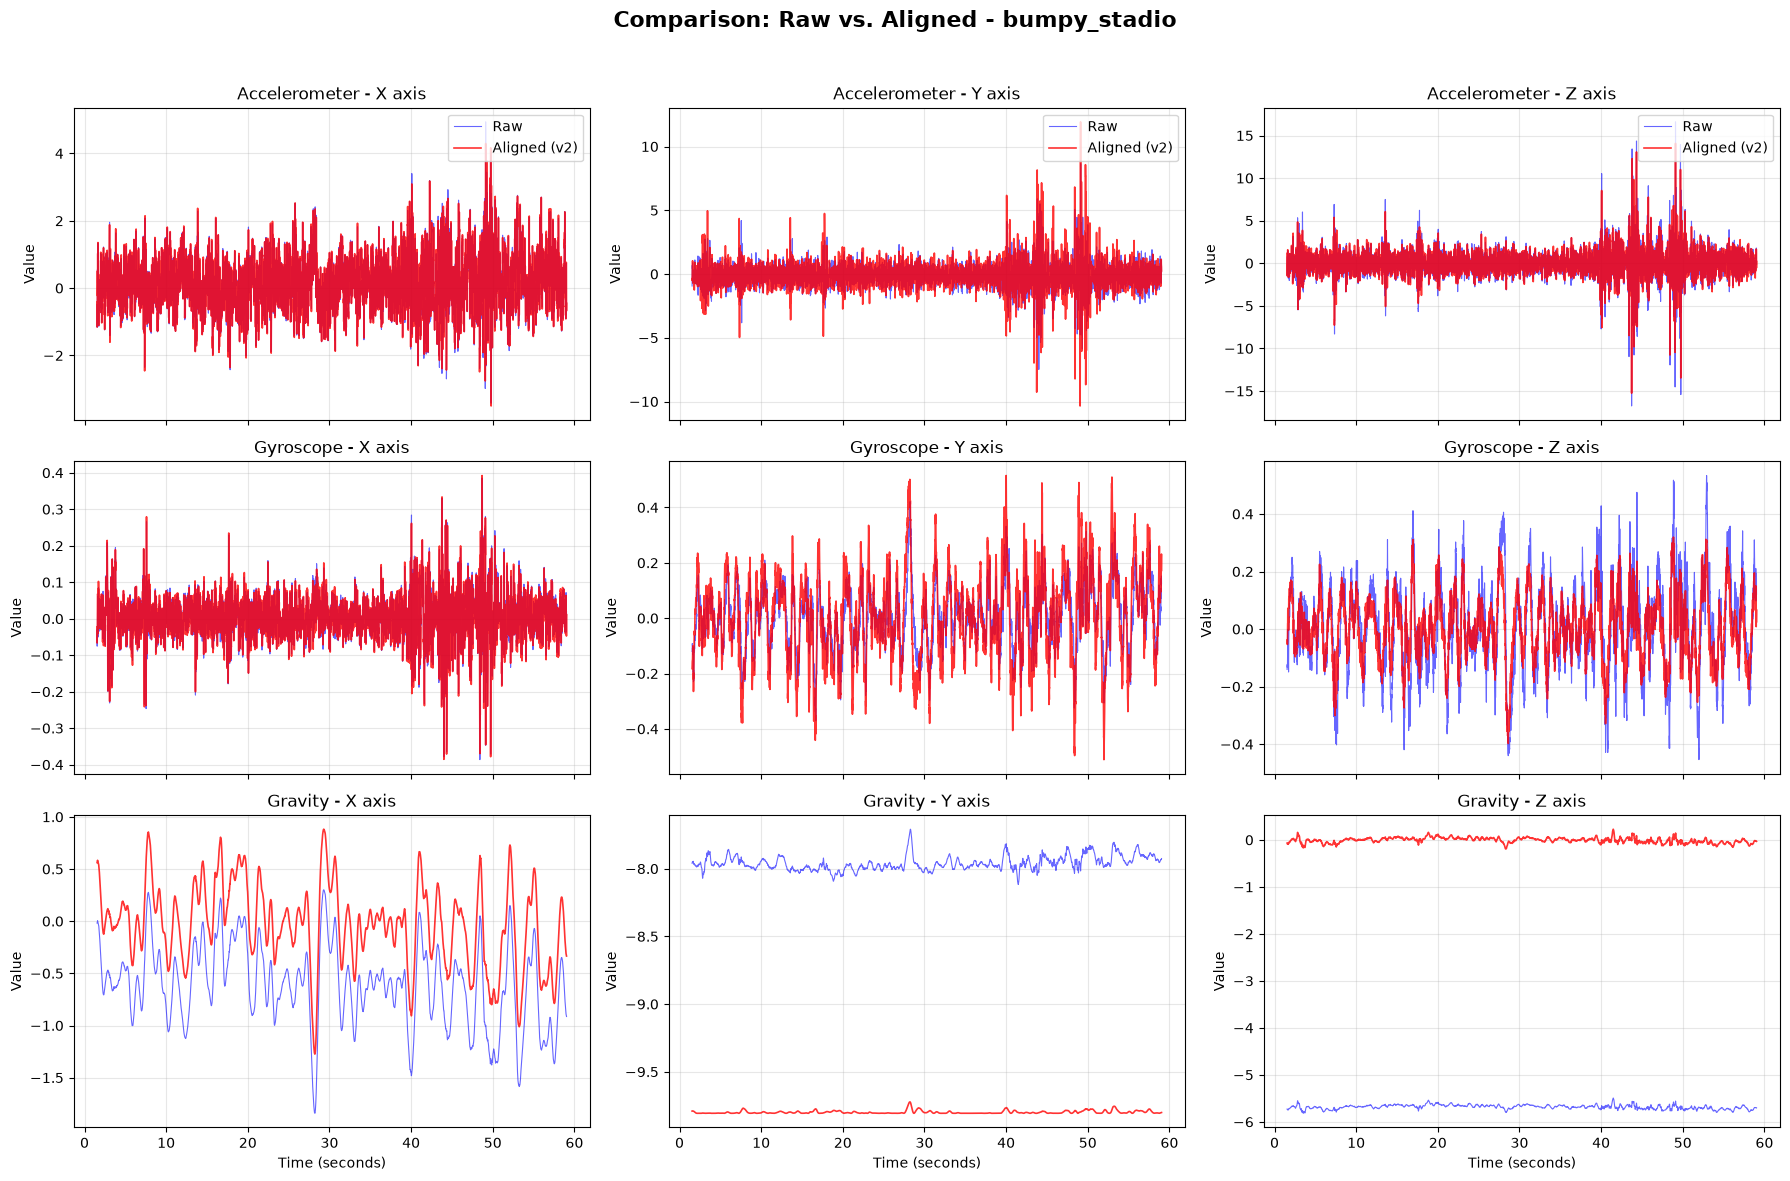

In [205]:
import os
import pandas as pd
import matplotlib.pyplot as plt


# Pick a recording to visualize (adjust if needed)
RECORDING = "bumpy_stadio" 

# Load data
sensors = ["Accelerometer", "Gyroscope", "Gravity"]
axes = ["x", "y", "z"]

fig, axs = plt.subplots(3, 3, figsize=(18, 12), sharex='col')
fig.suptitle(f'Comparison: Raw vs. Aligned - {RECORDING}', fontsize=16, fontweight='bold')

for i, sensor_type in enumerate(sensors):
    # Load raw and aligned data for the current sensor
    raw_path = os.path.join(INPUT_DIR_2, RECORDING, f"{sensor_type}.csv")
    aligned_path = os.path.join(OUTPUT_DIR_4, RECORDING, f"{sensor_type}_aligned.csv")
    
    if not os.path.exists(raw_path) or not os.path.exists(aligned_path):
        print(f"Skipping {sensor_type}: files not found.")
        continue
        
    raw_df = pd.read_csv(raw_path)
    aligned_df = pd.read_csv(aligned_path)
    
    # Use seconds_elapsed for X-axis (assuming it exists and is consistent)
    time = raw_df['seconds_elapsed'].values
    
    for j, axis in enumerate(axes):
        ax = axs[i, j]
        
        # Plot raw data
        ax.plot(time, raw_df[axis].values, label='Raw', color='blue', alpha=0.6, linewidth=0.8)
        
        # Plot aligned data
        ax.plot(time, aligned_df[axis].values, label='Aligned (v2)', color='red', alpha=0.8, linewidth=1.2)
        
        # Formatting
        ax.set_title(f'{sensor_type} - {axis.upper()} axis')
        ax.set_ylabel('Value')
        ax.grid(True, alpha=0.3)
        
        # Add legend only to the first row to avoid clutter
        if i == 0:
            ax.legend(loc='upper right')
            
        # Add X-axis label only to the bottom row
        if i == 2:
            ax.set_xlabel('Time (seconds)')

plt.tight_layout(rect=[0, 0, 1, 0.96]) # Adjust for suptitle
plt.show()

### Alignment Results Analysis ('bumpy_stadio' recording)

The comparison between raw sensor signals and post-alignment signals demonstrates the effectiveness of the static rotation matrix derived from the median gravity vector.



##### Key Observations

- **Gravity Vector Normalization (last plots row):**
  - **Y axis:** The gravitational acceleration component is successfully shifted from approximately $-7.9 \text{ m/s}^2$ to the target reference value of $-9.81 \text{ m/s}^2$, confirming that the vertical axis is now aligned straight down perpendicular to the road surface.
  - **X & Z axes:** Both lateral (X) and forward (Z) static offsets are zeroed out. The X-axis median shifts from $\sim -0.5 \text{ m/s}^2$ to $0 \text{ m/s}^2$, while the Z-axis baseline drops from $\sim -5.5 \text{ m/s}^2$ to $0 \text{ m/s}^2$.

- **Accelerometer & Gyroscope Dynamics (Top & Middle Rows):**
  - **Dynamic Invariance:** The transient high-frequency variations and impulse spikes caused by road roughness (e.g., around $t = 45\text{--}55\text{ s}$) are fully preserved in amplitude and shape across all axes.
  - **Spatial Redistribution:** Energy is correctly redistributed among the coordinate axes to reflect physical motion relative to the bicycle frame rather than the arbitrary orientation of the smartphone holder.


## Band pass filtering

### Design of the band pass filter

We want to apply a band pass filter to the recordings in order to isolate the relevant frequencies of the signal that are key to distinguish bumpy roads from smooth ones.
This will also be helpful to remove sensor noise and other components of the signal that can confuse the models.

In order to design an effective filter we need to first **analyze the frequencies** of both smooth and bumpy recordings, and identify the right cut off frequencies. This will enable us to cut noise and components that are too similar between bumpy and smooth roads while keeping the components that are key to distinguish the quality of the bike lane.


Before applying any filtering, it is essential to understand the **frequency characteristics** of our signals. By computing the FFT  for both smooth and bumpy road recordings, we ca for example:

1. **Identify discriminative frequency bands**: We can visually and quantitatively compare which frequencies are present in bumpy roads but absent (or minimal) in smooth roads. This reveals the "spectral signature" of road quality;

2. **Understand noise characteristics**: The FFT reveals high-frequency noise that should be removed, as well as low-frequency components (<1-2 Hz) related to normal driver movements (pedaling, steering ...) that are not relevant for bump detection.

3. **Avoid Signal Loss**: By examining the full spectrum first, we ensure we don't accidentally filter out the very frequencies that distinguish road conditions. This prevents us from discarding valuable information before feature extraction.


#### Accelerometer Spectral Analysis

We want to identify **discriminative frequency bands** that distinguish rough road vibrations from smooth riding conditions.

To do so we perform a **Power Spectral Density (PSD)** analysis on aligned accelerometer data to evaluate and compare the frequency signatures of bumpy vs. smooth road surfaces.

##### Pipeline

1) **Dataset categorization**: we scan the preprocessed data directory and classify recordings into two groups (`bumpy` and `smooth`) based on file naming conventions.

2) **Spectral Estimation (Welch's Method):**
   - **Detrending**: eliminate constant DC offsets and static gravity acceleration to isolate pure dynamic motion;
   - **PSD Computation:** apply Welch's method ($fs = 100\text{ Hz}$, Hann window, $N_{\text{perseg}} = 256$) to transform time-series acceleration into the frequency domain across the $X$, $Y$, and $Z$ axes.

3. **Statistical Aggregation:**
   - Converts power values to decibels ($\text{dB}$) and compute the **median** spectrum alongside the **25th–75th percentile range** (interquartile range) for each surface type and axis;

4. **Comparative Visualization:**
   - Plots three stacked subplots (one per axis) displaying the spectral profiles of bumpy (red) and smooth (blue) roads across the $0\text{--}50\text{ Hz}$ frequency range.


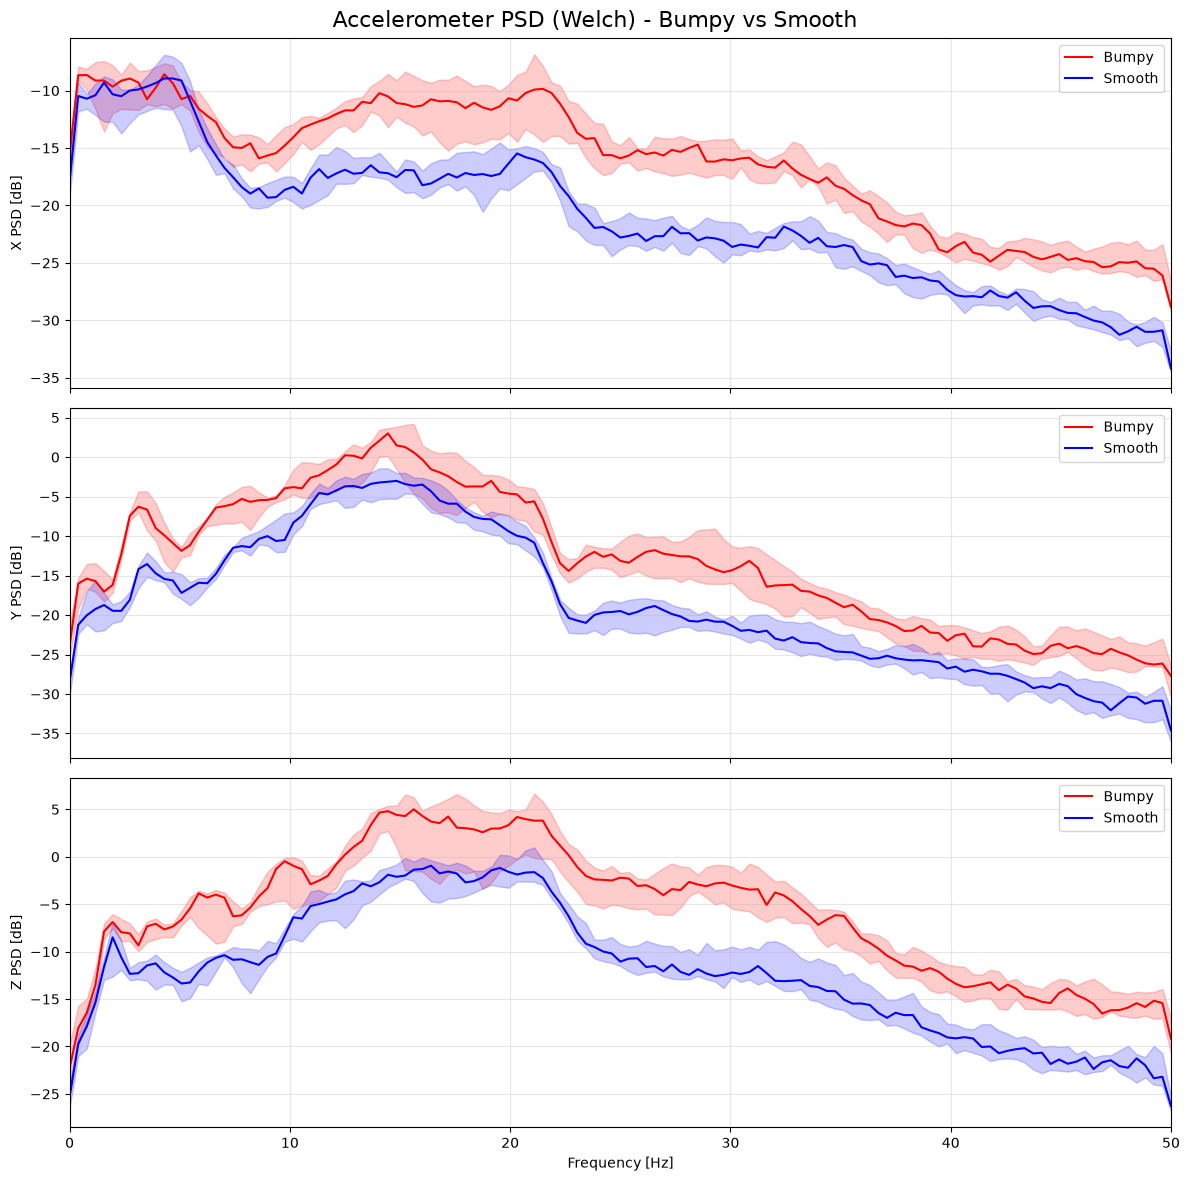

In [206]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal as sg
from scipy.stats import mannwhitneyu

OUTPUT_DIR_3 = "../preprocessing/cut_out_remove_stationary_aligned_definitive"
fs = 100
NPERSEG = 256

recs = os.listdir(OUTPUT_DIR_3)
bumpy = [r for r in recs if "bumpy" in r.lower()]
smooth = [r for r in recs if "smooth" in r.lower()]

def compute_psd(filepath, axis):
    x = pd.read_csv(filepath)[axis].values.astype(float)
    x = sg.detrend(x, type="constant")          # eliminates DC / gravity
    nperseg = min(NPERSEG, len(x))
    f, pxx = sg.welch(x, fs=fs, window="hann", nperseg=nperseg,
                      noverlap=nperseg // 2)
    return f, pxx

def collect(rec_list, axis):
    spectra, f_ref = [], None
    for r in rec_list:
        p = os.path.join(OUTPUT_DIR_3, r, "Accelerometer_aligned.csv")
        if not os.path.exists(p):
            continue
        f, pxx = compute_psd(p, axis)
        if f_ref is None:
            f_ref = f
        if len(f) == len(f_ref):                # same grid
            spectra.append(pxx)
    return f_ref, np.array(spectra)

fig, axs = plt.subplots(3, 1, figsize=(12, 12), sharex=True)
fig.suptitle("Accelerometer PSD (Welch) - Bumpy vs Smooth", fontsize=16)

for i, axis in enumerate(["x", "y", "z"]):
    f, B = collect(bumpy, axis)
    _, S = collect(smooth, axis)

    # --- PSD in dB: mediana e percentili 25-75 ---
    for data, color, label in [(B, "red", "Bumpy"), (S, "blue", "Smooth")]:
        db = 10 * np.log10(data + 1e-12)
        med = np.median(db, axis=0)
        q1, q3 = np.percentile(db, [25, 75], axis=0)

        axs[i].plot(f, med, color=color, label=label)
        axs[i].fill_between(f, q1, q3, color=color, alpha=0.2)

    axs[i].set_ylabel(f"{axis.upper()} PSD [dB]")
    axs[i].legend()
    axs[i].grid(alpha=0.3)

axs[-1].set_xlabel("Frequency [Hz]")
axs[0].set_xlim(0, 50)

plt.tight_layout()
plt.show()

#### Acelerometer spectral analysis: Results
The plots show how for each axis between the range $[20-50]Hz$ there's a clear difference of amplitudes for bumpy and smooth roads, with no overlapping between the 2.

The pass band filter will need to exclude frequencies outside of this range. Probably the higher frequencies (40-50 Hz) are caused by noise of the sensor or external factors that are not consistent (even if it looks like it inside of the graph). In order to be safe we'll to exclude even this frequency range.


**Final frequency range estimated in this step**: $[20-40] Hz$

---

### Gyroscope spectral analysis:

We do the same thing that we've done for the accelerometer for the Gyroscope but with these key differences:
- **Omission of Detrending:** skips the `sg.detrend()` step. Gyroscope readings do not measure static gravitational acceleration ($g$), so there is no large constant DC component to remove prior to spectral estimation.

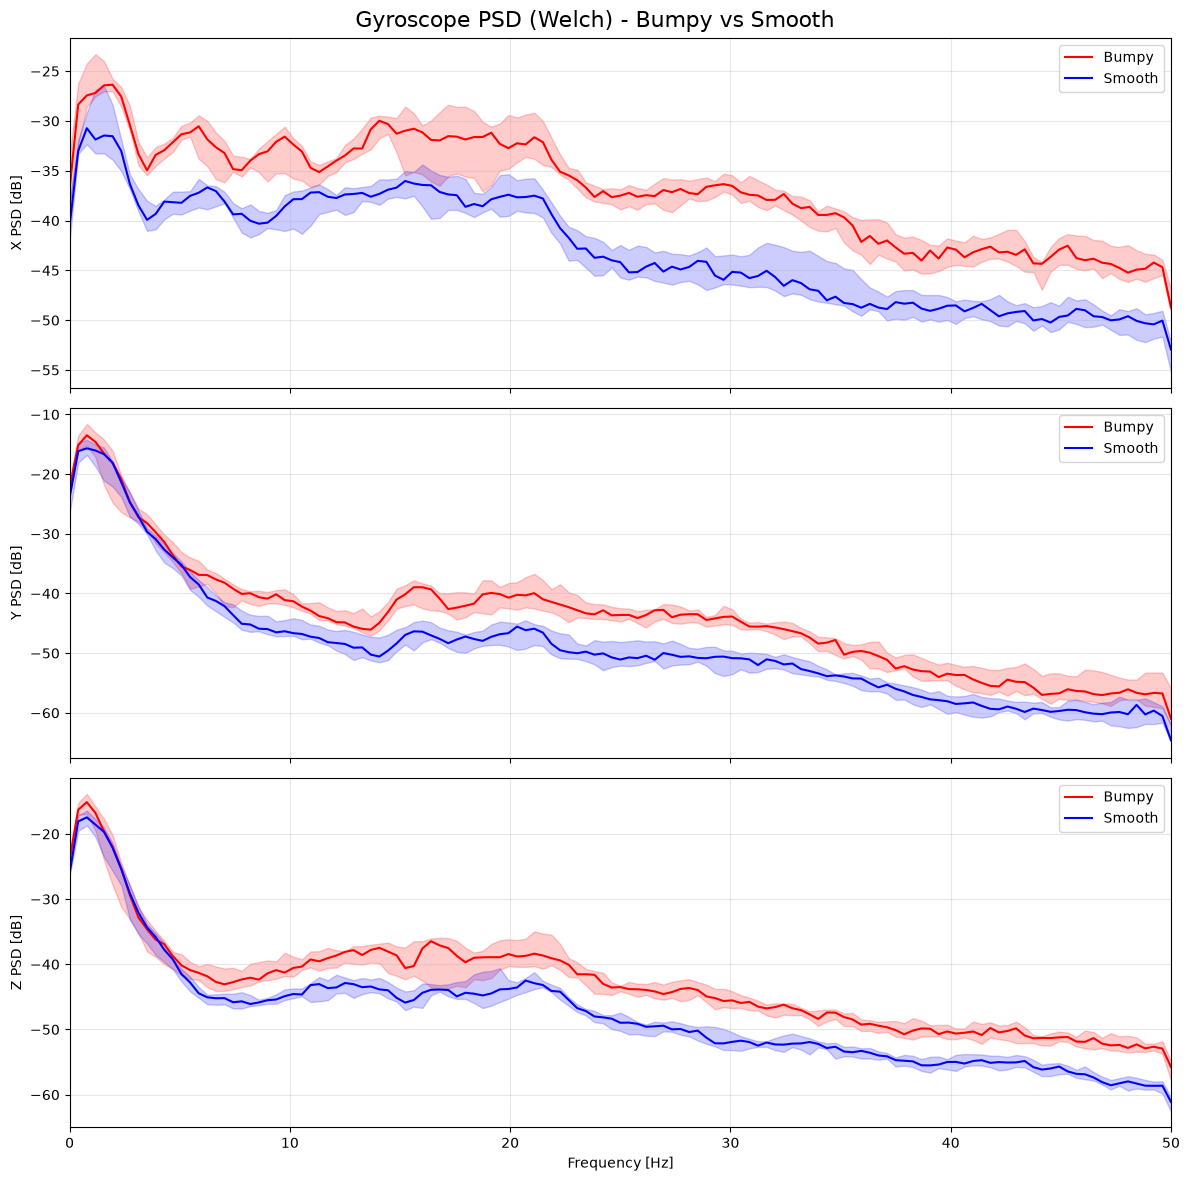

In [207]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal as sg

OUTPUT_DIR_3 = "../preprocessing/cut_out_remove_stationary_aligned_definitive"
fs = 100
NPERSEG = 256

recs = os.listdir(OUTPUT_DIR_3)
bumpy = [r for r in recs if "bumpy" in r.lower()]
smooth = [r for r in recs if "smooth" in r.lower()]

def compute_psd(filepath, axis):
    x = pd.read_csv(filepath)[axis].values.astype(float)
    nperseg = min(NPERSEG, len(x))
    f, pxx = sg.welch(x, fs=fs, window="hann", nperseg=nperseg,
                      noverlap=nperseg // 2)
    return f, pxx

def collect(rec_list, axis):
    spectra, f_ref = [], None
    for r in rec_list:
        p = os.path.join(OUTPUT_DIR_3, r, "Gyroscope_aligned.csv")
        if not os.path.exists(p):
            continue
        f, pxx = compute_psd(p, axis)
        if f_ref is None:
            f_ref = f
        if len(f) == len(f_ref):                # same grid
            spectra.append(pxx)
    return f_ref, np.array(spectra)

fig, axs = plt.subplots(3, 1, figsize=(12, 12), sharex=True)
fig.suptitle("Gyroscope PSD (Welch) - Bumpy vs Smooth", fontsize=16)

for i, axis in enumerate(["x", "y", "z"]):
    f, B = collect(bumpy, axis)
    _, S = collect(smooth, axis)

    # --- PSD in dB: mediana e percentili 25-75 ---
    for data, color, label in [(B, "red", "Bumpy"), (S, "blue", "Smooth")]:
        db = 10 * np.log10(data + 1e-12)
        med = np.median(db, axis=0)
        q1, q3 = np.percentile(db, [25, 75], axis=0)

        axs[i].plot(f, med, color=color, label=label)
        axs[i].fill_between(f, q1, q3, color=color, alpha=0.2)

    axs[i].set_ylabel(f"{axis.upper()} PSD [dB]")
    axs[i].legend()
    axs[i].grid(alpha=0.3)

axs[-1].set_xlabel("Frequency [Hz]")
axs[0].set_xlim(0, 50)

plt.tight_layout()
plt.show()

#### Gyroscope spectral analysis: Results
The plots show how for each axis between the range $[5-50]Hz$ there's a clear difference of amplitudes for bumpy and smooth roads, with no overlapping between the 2.

The pass band filter will need to exclude frequencies outside of this range. Probably the higher frequencies (40-50 Hz) are caused by noise of the sensor or external factors that are not consistent (even if it looks like it inside of the graph).

In order to be safe we'll exclude even this frequency range. Lower frequencies $[0-5 Hz)$ may represent normal street maneuvers like steering or turning rather than road conditions.Final frequency range estimated in this step: $[5-40] Hz$

### Accelerometer Spectral Analysis: Spectrogram

While Welch's PSD averages frequency content over time to provide a global power estimate for filter design, it loses all temporal dynamics.

We compute the spectrogram to observe how frequency power distribution evolves over time and to identify transient events (e.g., sharp shocks from bumps) relative to baseline road noise.

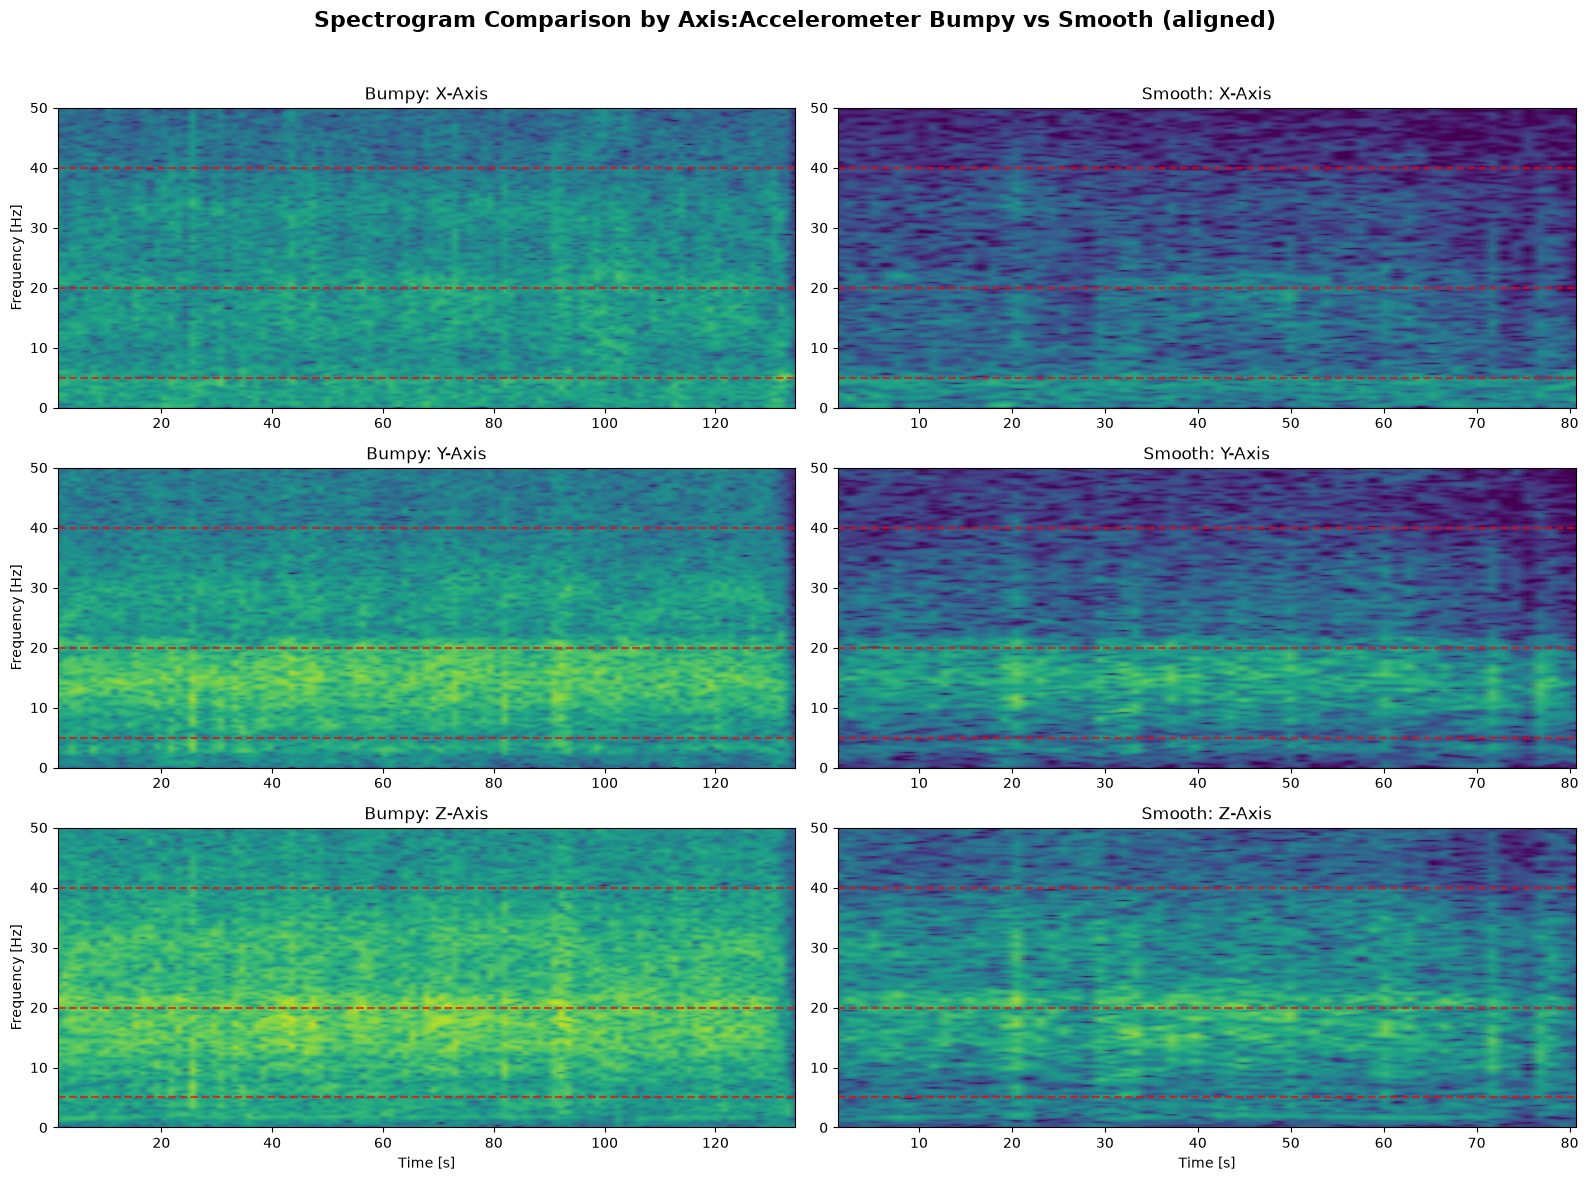

In [208]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
import os

OUTPUT_DIR_3 = "../preprocessing/cut_out_remove_stationary_aligned_definitive"

BUMPY_RECORDING = "bumpy_con_tante_buche-2026-09-21_13-24-26"
SMOOTH_RECORDING = "smooth_strada_universiya_ingresso-2026-09-21_13-29-22"
fs = 100

# Load data
bumpy_data = pd.read_csv(os.path.join(OUTPUT_DIR_3, BUMPY_RECORDING, "Accelerometer_aligned.csv"))
smooth_data = pd.read_csv(os.path.join(OUTPUT_DIR_3, SMOOTH_RECORDING, "Accelerometer_aligned.csv"))

time_bumpy = bumpy_data['seconds_elapsed'].values
time_smooth = smooth_data['seconds_elapsed'].values

# Spectrogram parameters
nperseg = 256
noverlap = nperseg // 2
nfft = 512

axes_to_plot = ['x', 'y', 'z']

# Create a 3x2 grid: 3 rows (X, Y, Z), 2 columns (Bumpy, Smooth)
fig, axs = plt.subplots(3, 2, figsize=(16, 12))
fig.suptitle('Spectrogram Comparison by Axis:Accelerometer Bumpy vs Smooth (aligned)', fontsize=16, fontweight='bold')

for row_idx, axis in enumerate(axes_to_plot):
    # Extract signal for the current axis
    sig_bumpy = bumpy_data[axis].values
    sig_smooth = smooth_data[axis].values
    
    # Compute spectrograms
    f_bumpy, t_bumpy, Sxx_bumpy = signal.spectrogram(sig_bumpy, fs=fs, nperseg=nperseg, noverlap=noverlap, nfft=nfft, scaling='density', window='hann')
    f_smooth, t_smooth, Sxx_smooth = signal.spectrogram(sig_smooth, fs=fs, nperseg=nperseg, noverlap=noverlap, nfft=nfft, scaling='density', window='hann')
    
    # --- Column 1: Bumpy ---
    im1 = axs[row_idx, 0].pcolormesh(t_bumpy, f_bumpy, 10 * np.log10(Sxx_bumpy + 1e-10), shading='gouraud', cmap='viridis', vmin=-60, vmax=25)
    axs[row_idx, 0].set_title(f'Bumpy: {axis.upper()}-Axis')
    axs[row_idx, 0].set_ylim(0, 50)
    axs[row_idx, 0].axhline(y=5, color='red', linestyle='--', alpha=0.7)
    axs[row_idx, 0].axhline(y=20, color='red', linestyle='--', alpha=0.7)
    axs[row_idx, 0].axhline(y=40, color='red', linestyle='--', alpha=0.7)
    if row_idx == 2:
        axs[row_idx, 0].set_xlabel('Time [s]')
    axs[row_idx, 0].set_ylabel('Frequency [Hz]')
    
    # --- Column 2: Smooth ---
    im2 = axs[row_idx, 1].pcolormesh(t_smooth, f_smooth, 10 * np.log10(Sxx_smooth + 1e-10), shading='gouraud', cmap='viridis', vmin=-40, vmax=20)
    axs[row_idx, 1].set_title(f'Smooth: {axis.upper()}-Axis')
    axs[row_idx, 1].set_ylim(0, 50)
    axs[row_idx, 1].axhline(y=5, color='red', linestyle='--', alpha=0.7)
    axs[row_idx, 1].axhline(y=20, color='red', linestyle='--', alpha=0.7)
    axs[row_idx, 1].axhline(y=40, color='red', linestyle='--', alpha=0.7)
    if row_idx == 2:
        axs[row_idx, 1].set_xlabel('Time [s]')

plt.tight_layout(rect=[0, 0, 1, 0.96]) # Adjust for suptitle
plt.show()

#### Spectrogram Analysis Acellerometer: Key Observations
- **Y-Axis (Vertical)**: Shows the strongest discriminative power. Bumpy roads exhibit sustained high-energy vibrations across **5-40 Hz**, while smooth roads remain mostly quiet (dark blue), especially at in frequencies higher than 20 HZ. 
- **X and Z Axes**: Bumpy recordings show elevated energy in the 10-30 Hz range compared to smooth, indicating lateral and longitudinal vibrations from road irregularities.


### Gyroscope Spectral Analysis: Spectrogram
We do the exact same for the gyroscope

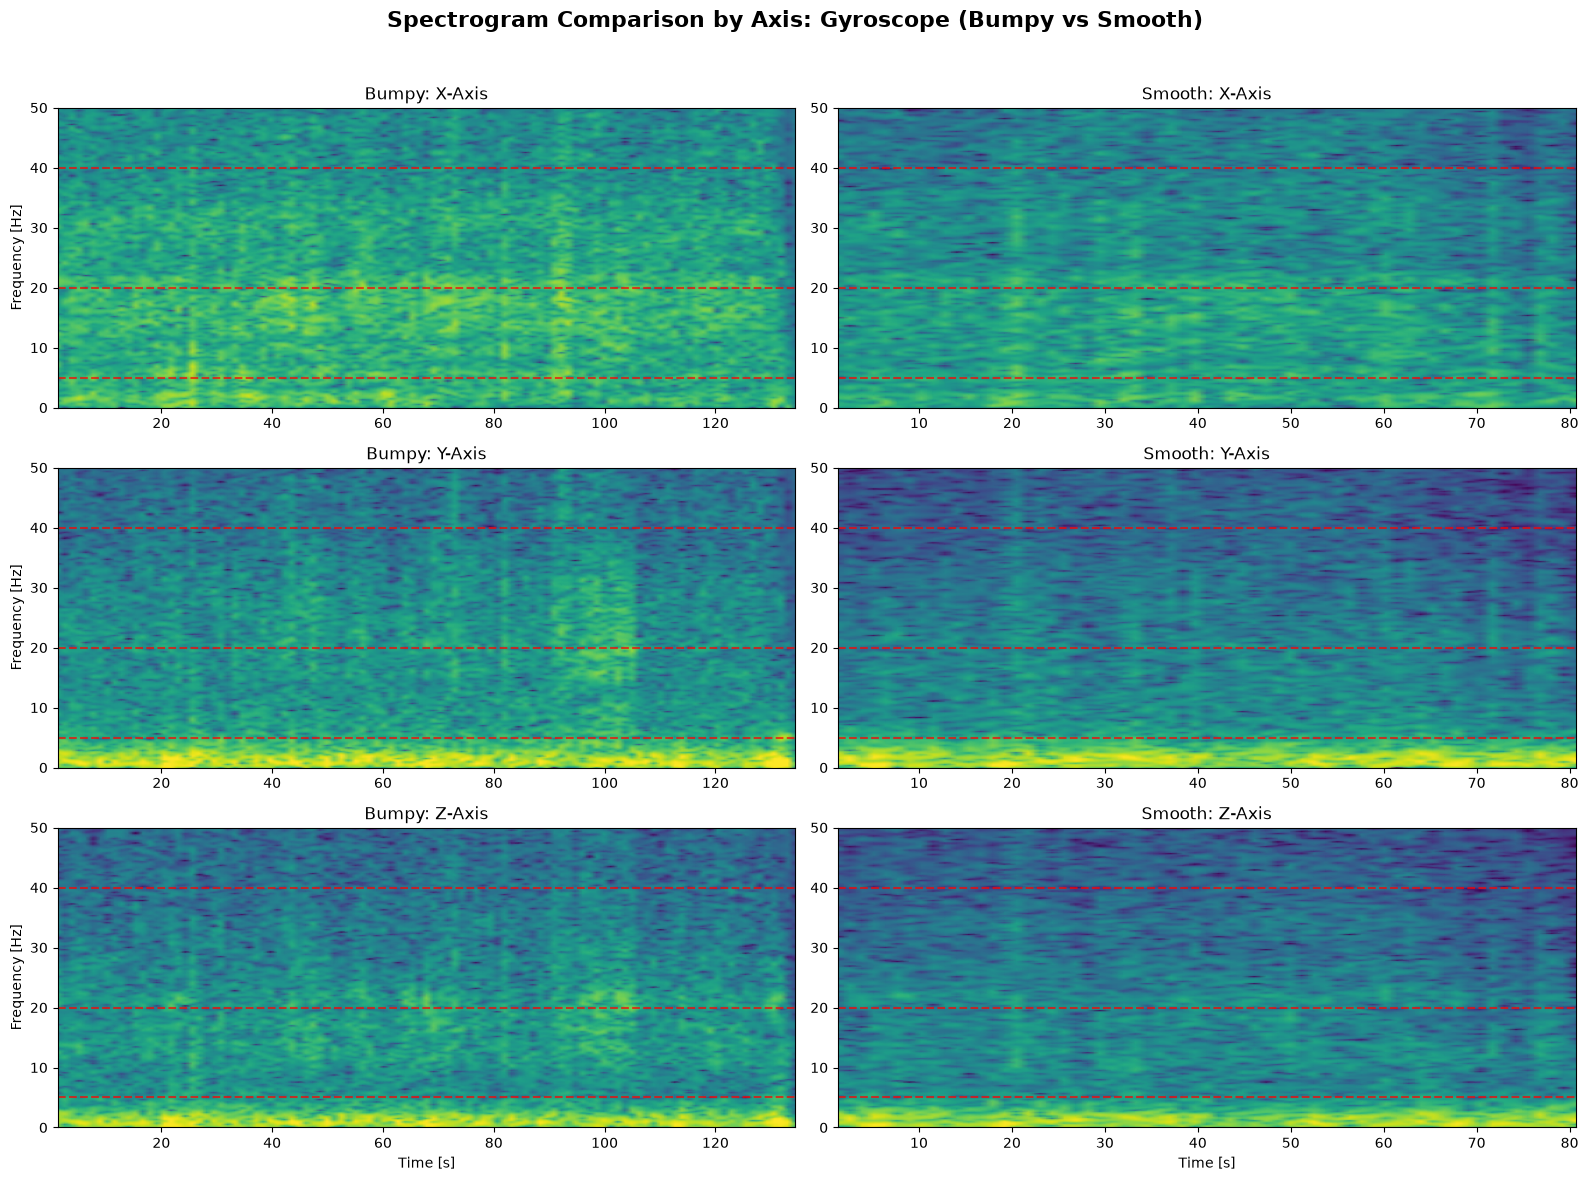

In [209]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
import os

OUTPUT_DIR_3 = "../preprocessing/cut_out_remove_stationary_aligned_definitive"

BUMPY_RECORDING = "bumpy_con_tante_buche-2026-09-21_13-24-26"
SMOOTH_RECORDING = "smooth_strada_universiya_ingresso-2026-09-21_13-29-22"
fs = 100

# Load data
bumpy_data = pd.read_csv(os.path.join(OUTPUT_DIR_3, BUMPY_RECORDING, "Gyroscope_aligned.csv"))
smooth_data = pd.read_csv(os.path.join(OUTPUT_DIR_3, SMOOTH_RECORDING, "Gyroscope_aligned.csv"))

time_bumpy = bumpy_data['seconds_elapsed'].values
time_smooth = smooth_data['seconds_elapsed'].values

# Spectrogram parameters
nperseg = 256
noverlap = nperseg // 2
nfft = 512

axes_to_plot = ['x', 'y', 'z']

# Create a 3x2 grid: 3 rows (X, Y, Z), 2 columns (Bumpy, Smooth)
fig, axs = plt.subplots(3, 2, figsize=(16, 12))
fig.suptitle('Spectrogram Comparison by Axis: Gyroscope (Bumpy vs Smooth)', fontsize=16, fontweight='bold')

for row_idx, axis in enumerate(axes_to_plot):
    # Extract signal for the current axis
    sig_bumpy = bumpy_data[axis].values
    sig_smooth = smooth_data[axis].values
    
    # Compute spectrograms
    f_bumpy, t_bumpy, Sxx_bumpy = signal.spectrogram(sig_bumpy, fs=fs, nperseg=nperseg, noverlap=noverlap, nfft=nfft, scaling='density', window='hann')
    f_smooth, t_smooth, Sxx_smooth = signal.spectrogram(sig_smooth, fs=fs, nperseg=nperseg, noverlap=noverlap, nfft=nfft, scaling='density', window='hann')
    
    # --- Column 1: Bumpy ---
    im1 = axs[row_idx, 0].pcolormesh(t_bumpy, f_bumpy, 10 * np.log10(Sxx_bumpy + 1e-10), shading='gouraud', cmap='viridis', vmin=-80, vmax=-10)
    axs[row_idx, 0].set_title(f'Bumpy: {axis.upper()}-Axis')
    axs[row_idx, 0].set_ylim(0, 50)
    axs[row_idx, 0].axhline(y=5, color='red', linestyle='--', alpha=0.7)
    axs[row_idx, 0].axhline(y=20, color='red', linestyle='--', alpha=0.7)
    axs[row_idx, 0].axhline(y=40, color='red', linestyle='--', alpha=0.7)
    if row_idx == 2:
        axs[row_idx, 0].set_xlabel('Time [s]')
    axs[row_idx, 0].set_ylabel('Frequency [Hz]')
    
    # --- Column 2: Smooth ---
    im2 = axs[row_idx, 1].pcolormesh(t_smooth, f_smooth, 10 * np.log10(Sxx_smooth + 1e-10), shading='gouraud', cmap='viridis', vmin=-80, vmax=-10)
    axs[row_idx, 1].set_title(f'Smooth: {axis.upper()}-Axis')
    axs[row_idx, 1].set_ylim(0, 50)
    axs[row_idx, 1].axhline(y=5, color='red', linestyle='--', alpha=0.7)
    axs[row_idx, 1].axhline(y=20, color='red', linestyle='--', alpha=0.7)
    axs[row_idx, 1].axhline(y=40, color='red', linestyle='--', alpha=0.7)
    if row_idx == 2:
        axs[row_idx, 1].set_xlabel('Time [s]')

plt.tight_layout(rect=[0, 0, 1, 0.96]) # Adjust for suptitle
plt.show()

#### Spectrogram Analysis Gyroscope: Key Observations
- **Y-Axis**: Clear separation right after 5 Hz.
- **X-Axis**: Bumpy roads show increased energy in the **10-40 Hz band**, suggesting high-frequency lateral vibrations/frame twist.
- **Z-Axis**: Minimal activity on both road types, as expected for straight riding.

**Overall Pattern:**
Bumpy roads produce **sustained, broadband energy** across multiple frequency bands and axes, while smooth roads show only low-frequency content (<5 Hz) from normal riding dynamics. The clear visual separation validates that our alignment successfully isolated axis-specific vibration signatures.

## Bandpass Filtering (Per Continuous Segment)
We want to isolate the relevant vibration frequencies that we found during the analysis we just conducted.

To do so, we implement a bandpass filter applied individually to aligned accelerometer and gyroscope signals after splitting recordings into continuous, gap-free segments (discontinous jumps result in the time domain result into unexpected frequency components that pollute the signal).

**Pipeline**:
1) **Sensor Merging & Synchronized Loading**: We load Accelerometer_aligned.csv and Gyroscope_aligned.csv for each recording, merging them into a single unified DataFrame with a shared seconds_elapsed timeline to ensure perfect cross-sensor alignment;

2) **Temporal Gap Splitting**: We detect temporal gaps in seconds_elapsed (where $\Delta t > 0.2\text{ s}$) resulting from the previous stationary segment removal step. The we split the recording into separate continuous segments;

3) **Sensor-Specific Bandpass Filtering**: we create a bandpass filter tailored to each sensor type based on our previous spectral analysis results ($[10-40]Hz$ for the accelerometer and $[5-40]Hz$ for the gyroscope);

In [210]:
import os
import numpy as np
import pandas as pd
from scipy.signal import butter, filtfilt

# ---------------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------------
INPUT_DIR = "../preprocessing/cut_out_remove_stationary_aligned_definitive"
FS = 100

# Per-sensor filter parameters
FILTER_CONFIG = {
    "acc": {"lowcut": 10.0, "highcut": 40.0, "order": 4},
    "gyr": {"lowcut": 5.0,  "highcut": 40.0, "order": 4},
}

GAP_THRESHOLD = 0.2       # seconds; 0.2s used for safety (nominal sample period is 0.01s)
MIN_SEGMENT_LENGTH = 50   # discard segments shorter than 0.5s

AXES = ("x", "y", "z")


# ---------------------------------------------------------------------------
# Filter design
# ---------------------------------------------------------------------------
def design_butterworth(order, lowcut, highcut, fs, btype='band'):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    return butter(order, [low, high], btype=btype)


# One (b, a) pair per sensor, designed once
FILTERS = {
    sensor: design_butterworth(cfg["order"], cfg["lowcut"], cfg["highcut"], FS)
    for sensor, cfg in FILTER_CONFIG.items()
}

# Column names for each sensor, e.g. {"acc": ["acc_x", "acc_y", "acc_z"], ...}
CHANNELS = {sensor: [f"{sensor}_{ax}" for ax in AXES] for sensor in FILTERS}


# ---------------------------------------------------------------------------
# Helpers
# ---------------------------------------------------------------------------
def load_recording(rec_path, recording):
    """Load accelerometer and gyroscope CSVs and merge them into one DataFrame."""
    acc_path = os.path.join(rec_path, "Accelerometer_aligned.csv")
    gyr_path = os.path.join(rec_path, "Gyroscope_aligned.csv")

    if not (os.path.exists(acc_path) and os.path.exists(gyr_path)):
        return None

    acc_df = pd.read_csv(acc_path)
    gyr_df = pd.read_csv(gyr_path)

    assert len(acc_df) == len(gyr_df), (
        f"Length mismatch in {recording}: acc={len(acc_df)}, gyr={len(gyr_df)}"
    )

    # Combined structure to keep sensors time-synchronized for later windowing
    df = pd.DataFrame({"seconds_elapsed": acc_df["seconds_elapsed"]})
    for ax in AXES:
        df[f"acc_{ax}"] = acc_df[ax]
    for ax in AXES:
        df[f"gyr_{ax}"] = gyr_df[ax]
    return df


def split_at_gaps(df, gap_threshold):
    """Split a DataFrame into continuous segments at temporal gaps."""
    dt = df["seconds_elapsed"].diff()
    gap_indices = np.where(dt > gap_threshold)[0]
    if len(gap_indices) > 0:
        print(f"Splitted recording into {len(gap_indices) + 1} continoous recordings")
    boundaries = [0, *gap_indices, len(df)]
    return [df.iloc[boundaries[i]:boundaries[i + 1]] for i in range(len(boundaries) - 1)]


def filter_segment(segment):
    """Apply the sensor-specific bandpass filter to each channel of a segment."""
    filtered = segment.copy()
    for sensor, (b, a) in FILTERS.items():
        for ch in CHANNELS[sensor]:
            filtered[ch] = filtfilt(b, a, segment[ch].values)
    return filtered


# ---------------------------------------------------------------------------
# Main
# ---------------------------------------------------------------------------
def main():
    filtered_segments = []

    for recording in os.listdir(INPUT_DIR):
        rec_path = os.path.join(INPUT_DIR, recording)
        if not os.path.isdir(rec_path):
            continue

        df = load_recording(rec_path, recording)
        if df is None:
            continue

        for segment in split_at_gaps(df, GAP_THRESHOLD): # Split recordings into more than one if there's at least one stationary cutout
            if len(segment) < MIN_SEGMENT_LENGTH:
                continue

            filtered_segment = filter_segment(segment)
            filtered_segment["recording_name"] = recording
            filtered_segments.append(filtered_segment)

    print(f"Generated {len(filtered_segments)} filtered continuous segments.")
    return filtered_segments


if __name__ == "__main__":
    filtered_segments = main()

Splitted recording into 3 continoous recordings
Splitted recording into 2 continoous recordings
Generated 30 filtered continuous segments.


## Windowing and Labeling

Here we create the windows and assign the label based on the *recording_name* we saved in the previous step.

We extract 3s windows with 30% overlap.
- **The 3 second window size** has been chosen in order to remain temporally localized while ensuring sufficient temporal coverage to capture isolated bump events on not so bumpy (but still classified as bumpy);
- **Why overlap?** It increases our training observations (critical given limited sessions) and ensures a transient event (like a single pothole) isn't split exactly on a window boundary, which would dilute its signature in both adjacent windows.

In [211]:
WINDOW_SEC = 3
OVERLAP = 0.3
WINDOW_SAMPLES = int(WINDOW_SEC * FS)
STEP_SAMPLES = int(WINDOW_SAMPLES * (1 - OVERLAP))

windows_data = []

# Group segments by recording to derive the label once per recording
from collections import defaultdict
segments_by_recording = defaultdict(list)

# Group segments by recording name
for seg in filtered_segments:
    segments_by_recording[seg['recording_name'].iloc[0]].append(seg)

for recording_name, segments in segments_by_recording.items():
    # Determine label based on recording name
    label = 1 if "bumpy" in recording_name.lower() else 0 if "smooth" in recording_name.lower() else None # bumpy => 1, smooth => 0, else None
    
    if label is None:
        print(f"Warning: Could not determine label for recording {recording_name}. Skipping.")
        continue

    print(f"Labelled recording \"{recording_name}\" as {"bumpy" if label == 1 else "smooth"} ")
    
    for segment in segments:
        segment_length = len(segment)
        if segment_length < WINDOW_SAMPLES:
            continue  # Skip segments shorter than the window size

        for start in range(0, segment_length - WINDOW_SAMPLES + 1, STEP_SAMPLES):
            window = segment.iloc[start:start + WINDOW_SAMPLES].copy()

            t_start = window['seconds_elapsed'].iloc[0]
            t_end = window['seconds_elapsed'].iloc[-1]

            # Safety check: Ensure the window does not have residual gaps by checking the time difference
            if (t_end - t_start) > ( WINDOW_SEC + 0.1):
                print("WARNING: found non continous segment")
                continue  # Skip windows that have a gap (stationary cut out) in them

            # Store the window data along with its label
            windows_data.append({
                'group_id': recording_name,
                'label': label,
                'data': window
            })
print(f"Created {len(windows_data)} total windows")

Labelled recording "bumpy_Campus-2026-10-03_18-33-15" as bumpy 
Labelled recording "bumpy_casa-2026-10-04_10-31-51" as bumpy 
Labelled recording "bumpy_con_tante_buche-2026-09-21_13-24-26" as bumpy 
Labelled recording "bumpy_con_una_grande_curva_alla_fine-2026-09-21_13-47-25" as bumpy 
Labelled recording "bumpy_park-2026-10-04_11-55-42" as bumpy 
Labelled recording "bumpy_stadio" as bumpy 
Labelled recording "bumpy_station-2026-10-04_10-33-25" as bumpy 
Labelled recording "bumpy_station2-2026-10-04_11-51-56" as bumpy 
Labelled recording "bumpy_stazione" as bumpy 
Labelled recording "bumpy_stradabumpy_con_rialzi_e_buche-2026-09-21_13-44-51" as bumpy 
Labelled recording "bumpy_swapfiets" as bumpy 
Labelled recording "smooth_con_fermata-2026-09-23_14-28-20" as smooth 
Labelled recording "smooth_con_fermata_2-2026-09-23_14-35-33" as smooth 
Labelled recording "smooth_con_un_po_di_rialzi_e_piccoli_tratti_saltellanti-2026-09-21_13-33-45" as smooth 
Labelled recording "smooth_grande_curva_apl

# 2. Feature Extraction

Now that we have our nicely preprocessed recordings we can proceed to extract new features from them, in order to have more and (hopefully) more significative data that can then be selected in the feature selection step.


To do so for each 3 second window, we extract 18 distinct features across all 6 channels (Accelerometer X/Y/Z and Gyroscope X/Y/Z), resulting in 108 physical descriptors per window. These features are divided into two categories based on their physical meaning:

#### Time-Domain Features

* **Mean (mean):** Captures residual signal offset or baseline amplitude within the window;
* **Standard Deviation (std):** Measures overall signal dispersion and vibration intensity around the mean;
* **Root Mean Square (rms):** Quantifies total signal energy and power content;
* **Maximum (max):** Captures the highest magnitude positive peak caused by sudden shocks or impacts;
* **Minimum (min):** Captures the largest negative excursion in the windowed signal;
* **Peak-to-Peak (peak_to_peak):** Evaluates the total dynamic range ($max - min$) of vibration within the window;
* **Peak Count (peak_count):** Counts prominent local transient spikes ($> 0.5 \times \text{std}$ from mean) to quantify impact frequency;
* **Energy (energy):** Computes total cumulative time-domain energy ($\sum x^2$).

#### Frequency-Domain Features

* **Dominant Frequency (dominant_freq):** Identifies the frequency with maximum power spectral density inside the sensor passband;
* **Spectral Centroid (spectral_centroid):** Locates the center of mass of the power spectrum, representing the average frequency of vibration;
* **Spectral Entropy (spectral_entropy):** Measures frequency distribution randomness; higher values indicate noisy, irregular surface impacts (bumpy), while lower values indicate tonal, structured vibrations (smooth);
* **Geometric Mean (geometric_mean):** Computes the geometric average of normalized passband PSD power;
* **Arithmetic Mean (arithmetic_mean):** Computes the standard arithmetic average of normalized passband PSD power;
* **Spectral Flatness (spectral_flatness):** Evaluates how noise-like or tonal a signal is ($\text{Geometric Mean} / \text{Arithmetic Mean}$); values close to 1 represent white noise (rough surface), while values near 0 indicate concentrated peaks;
* **Band Energy (band_energy_lo_hiHz):** Sums PSD power across specific sub-bands ($10\text{--}20$, $20\text{--}30$, $30\text{--}40 \text{ Hz}$ for accelerometer; $5\text{--}10$, $10\text{--}20$, $20\text{--}30$, $30\text{--}40 \text{ Hz}$ for gyroscope) to isolate distinct surface vibration signatures.

By translating raw waveforms into these physical descriptors, we provide the machine learning model with a comprehensive, interpretable representation of the road's mechanical behavior.

In [212]:
import numpy as np
import pandas as pd
from scipy.signal import welch, find_peaks

FS = 100
# Per-sensor filter parameters
FILTER_CONFIG = {
    "acc": {"lowcut": 10.0, "highcut": 40.0, "order": 4},
    "gyr": {"lowcut": 5.0,  "highcut": 40.0, "order": 4},
}

# Band-energy bands per sensor: only bands inside the filter passband are meaningful.
BANDS = {
    "acc": [(10, 20), (20, 30), (30, 40)],
    "gyr": [(5, 10), (10, 20), (20, 30), (30, 40)],
}

CHANNELS = ["acc_x", "acc_y", "acc_z", "gyr_x", "gyr_y", "gyr_z"]


def _band_name(lo, hi):
    return f"band_energy_{lo}_{hi}Hz"


def get_feature_names(sensor):
    """Ordered list of feature names for a given sensor ('acc' or 'gyr')."""
    return [
        "mean", "std", "rms", "max", "min", "peak_to_peak", "peak_count", "energy",
        "dominant_freq", "spectral_centroid", "spectral_entropy",
        "geometric_mean", "arithmetic_mean", "spectral_flatness",
        *[_band_name(lo, hi) for lo, hi in BANDS[sensor]],
    ]


def extract_features(signal_1d, sensor_type, fs=FS):
    """
    Extracts time-domain and frequency-domain features from a 1D signal
    that was bandpass-filtered with the filter of the given sensor ('acc' or 'gyr').
    Spectral features are computed only inside that sensor's passband.
    """
    n = len(signal_1d)
    if n == 0:
        return {name: np.nan for name in get_feature_names(sensor_type)}

    lowcut = FILTER_CONFIG[sensor_type]["lowcut"]
    highcut = FILTER_CONFIG[sensor_type]["highcut"]

    # ---------------- Time-domain ----------------
    mean_val = np.mean(signal_1d)
    std_val = np.std(signal_1d)
    rms_val = np.sqrt(np.mean(signal_1d ** 2))
    max_val = np.max(signal_1d)
    min_val = np.min(signal_1d)
    energy = np.sum(signal_1d ** 2)

    # Peaks of the absolute deviation from the mean, above 0.5 * std
    peaks, _ = find_peaks(np.abs(signal_1d - mean_val), height=0.5 * std_val)

    # ---------------- Frequency-domain (Welch) ----------------
    nperseg = n // 2
    if nperseg < 16:
        nperseg = n
    freqs, psd = welch(signal_1d, fs=fs, nperseg=nperseg)

    # Restrict to the passband: outside it the PSD is just filter roll-off,
    # which would distort centroid, entropy and flatness.
    pb = (freqs >= lowcut) & (freqs <= highcut)
    f_pb, psd_pb = freqs[pb], psd[pb]

    psd_sum = max(np.sum(psd_pb), 1e-10)
    psd_norm = psd_pb / psd_sum
    eps = 1e-10

    dominant_freq = f_pb[np.argmax(psd_pb)]
    spectral_centroid = np.sum(f_pb * psd_norm)
    spectral_entropy = -np.sum(psd_norm * np.log2(psd_norm + eps))
    # Geometric and arithmetic mean of the normalized PSD (within the passband)
    geometric_mean = np.exp(np.mean(np.log(psd_norm + eps)))
    arithmetic_mean = np.mean(psd_norm)
    spectral_flatness = geometric_mean / arithmetic_mean

    features = {
        "mean": mean_val,
        "std": std_val,
        "rms": rms_val,
        "max": max_val,
        "min": min_val,
        "peak_to_peak": max_val - min_val,
        "peak_count": len(peaks),
        "energy": energy,
        "dominant_freq": dominant_freq,
        "spectral_centroid": spectral_centroid,
        "spectral_entropy": spectral_entropy,
        "geometric_mean": geometric_mean,
        "arithmetic_mean": arithmetic_mean,
        "spectral_flatness": spectral_flatness,
    }

    # Sensor-specific band energies (last band includes its upper edge)
    bands = BANDS[sensor_type]
    for i, (lo, hi) in enumerate(bands):
        upper = (freqs <= hi) if i == len(bands) - 1 else (freqs < hi)
        features[_band_name(lo, hi)] = np.sum(psd[(freqs >= lo) & upper])

    return features


# ---------------------------------------------------------------------------
# Build the feature table
# ---------------------------------------------------------------------------
feature_rows = [] # array of dictionaries 

for window in windows_data:
    df_window = window["data"]
    feature_row = {
        "group_id": window["group_id"],
        "label": window["label"],
    }

    for ch in CHANNELS:
        sensor_type = ch.split("_")[0]  # acc or gyr
        features = extract_features(df_window[ch].values, sensor_type)
        for feature_name, value in features.items():
            feature_row[f"{ch}_{feature_name}"] = value

    feature_rows.append(feature_row)

feature_table = pd.DataFrame(feature_rows)
print(f"Feature table created with shape: {feature_table.shape}")

# Data integrity check
nan_count = feature_table.isna().sum().sum()
print(f"Total NaN values in dataset: {nan_count}")
if nan_count > 0:
    print("Warning: NaNs detected. Check for extremely short windows.")

print(feature_table.head(5))
print("Columns in the feature table:")
print(feature_table.columns.tolist())

feature_table.to_csv("feature_table_definitive.csv", index=False)

Feature table created with shape: (882, 107)
Total NaN values in dataset: 0
                           group_id  label  acc_x_mean  acc_x_std  acc_x_rms  \
0  bumpy_Campus-2026-10-03_18-33-15      1   -0.003987   1.894831   1.894836   
1  bumpy_Campus-2026-10-03_18-33-15      1    0.005301   1.182817   1.182829   
2  bumpy_Campus-2026-10-03_18-33-15      1    0.009454   1.496085   1.496115   
3  bumpy_Campus-2026-10-03_18-33-15      1   -0.003079   1.442554   1.442557   
4  bumpy_Campus-2026-10-03_18-33-15      1    0.002584   2.078166   2.078168   

   acc_x_max  acc_x_min  acc_x_peak_to_peak  acc_x_peak_count  acc_x_energy  \
0  10.942090 -10.163462           21.105552                79   1077.120511   
1   4.232700  -4.885573            9.118274               101    419.725119   
2   4.800031  -4.885573            9.685604                91    671.508296   
3   4.436008  -4.325709            8.761717               102    624.291620   
4   7.270093  -9.215694           16.485787     

## **4. Feature Selection**

### **Supervised Models**
Feature selection for KNN, Logistic Regression, Random Forest and SVM follows these steps:

1. **Split by recording.** Whole recordings are assigned to one set only, taking the same share of recordings from each class:
   - **test** (15% of the recordings): kept aside and used only for the final evaluation;
   - **validation** (20% of the remaining recordings): used to score candidate feature sets;
   - **inner train** (the rest): used to compute the filters and to fit the models.
2. **Mutual Information ranking.** Features are ranked by their MI with the label, in decreasing order, computed on the inner train only.
3. **Correlation filter.** Going down the MI ranking, a feature is kept only if its absolute correlation with every feature already kept is ≤ 0.8 (computed on the inner train only).
4. **Greedy selection (per model).** The remaining features are tried in MI order. For each one, the model is trained on the inner train and its macro F1 is measured on the validation set. A feature is added if:
   - fewer than 4 features have been selected, or
   - it improves the validation F1 of the current set by more than 0.01.

   Selection stops at 12 features.

The selected features for each model are stored in `model_selected_features`. The validation F1 is optimistic, because it was used to choose the features, so model performance is reported on the test set only.

In [ ]:
# =============================================================================
# Supervised feature selection with a static split by recording
#
#   feature_table ──► TEST (kept aside, used only for the final evaluation)
#                └──► TRAIN ──► INNER TRAIN  (MI, correlation, model fitting)
#                          └──► VALIDATION   (scores the candidate feature sets)
# =============================================================================


import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

RANDOM_STATE = 42
TEST_FRACTION = 0.15        # share of the recordings of each class kept for the test set
VALIDATION_FRACTION = 0.20  # share of the training recordings of each class used for validation
CORRELATION_THRESHOLD = 0.8
MIN_FEATURES = 4            # the first MIN_FEATURES candidates are always added
MAX_FEATURES = 12
MIN_IMPROVEMENT = 0.01      # minimum gain in validation F1 needed to add a feature

models_dict = {
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "RandomForest": RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
    "SVM": SVC(kernel="rbf", random_state=RANDOM_STATE),
}


# -----------------------------------------------------------------------------
# Helper functions
# -----------------------------------------------------------------------------
def split_by_recording(data, fraction, seed):
    """
    Move whole recordings (group_id) to the held-out set, taking the same share
    of recordings from each class, so both classes are always present.
    Returns (kept_set, held_out_set).
    """
    recording_labels = data.groupby("group_id")["label"].first()
    rng = np.random.default_rng(seed)

    held_out_recordings = []
    for label in sorted(recording_labels.unique()):
        recordings = sorted(recording_labels[recording_labels == label].index)
        n_held_out = max(1, round(fraction * len(recordings)))
        held_out_recordings += list(rng.choice(recordings, size=n_held_out, replace=False))

    is_held_out = data["group_id"].isin(held_out_recordings)
    return data[~is_held_out].copy(), data[is_held_out].copy()


def describe_split(name, data):
    """Print how many recordings and windows of each class a set contains."""
    recordings = data.groupby("group_id")["label"].first()
    n_bumpy, n_smooth = (recordings == 1).sum(), (recordings == 0).sum()
    print(f"{name:<12} {n_bumpy:>2} bumpy + {n_smooth:>2} smooth recordings, {len(data):>4} windows")


def rank_by_mutual_information(data, feature_cols):
    """Mutual information of each feature with the label, sorted in decreasing order."""
    mi_scores = mutual_info_classif(data[feature_cols], data["label"], random_state=RANDOM_STATE)
    return pd.Series(mi_scores, index=feature_cols).sort_values(ascending=False)


def remove_correlated_features(data, ranked_features):
    """
    Walk the features from highest to lowest MI and keep a feature only if its
    |correlation| with every feature already kept is <= CORRELATION_THRESHOLD.
    """
    corr_matrix = data[ranked_features].corr().abs()
    kept_features = []
    for feature in ranked_features:
        too_similar = any(corr_matrix.loc[feature, kept] > CORRELATION_THRESHOLD for kept in kept_features)
        if not too_similar:
            kept_features.append(feature)
    return kept_features


def validation_f1(model, features, train_data, val_data):
    """Fit scaler and model on train_data, return the macro F1 on val_data."""
    scaler = StandardScaler()
    X_train = scaler.fit_transform(train_data[features])
    X_val = scaler.transform(val_data[features])

    fitted_model = clone(model).fit(X_train, train_data["label"])
    y_pred = fitted_model.predict(X_val)
    return f1_score(val_data["label"], y_pred, average="macro")


def greedy_selection(model, candidates, train_data, val_data):
    """
    Try the candidates in MI order. A feature is added if:
      - fewer than MIN_FEATURES features are selected (forced), or
      - it improves the validation F1 of the current set by more than MIN_IMPROVEMENT.
    Stops at MAX_FEATURES. Returns the selected features and their validation F1.
    """
    selected = []
    current_score = None  # validation F1 of the currently selected set

    for feature in candidates:
        if len(selected) == MAX_FEATURES:
            break

        trial_score = validation_f1(model, selected + [feature], train_data, val_data)

        if len(selected) < MIN_FEATURES:
            reason = "forced (minimum not reached)"
        elif trial_score > current_score + MIN_IMPROVEMENT:
            reason = f"improvement of {trial_score - current_score:+.4f}"
        else:
            continue  # rejected: the current set and its score stay unchanged

        selected.append(feature)
        current_score = trial_score
        print(f"\t+ {feature:<32} F1 = {trial_score:.4f}   [{reason}]")

    return selected, current_score


# -----------------------------------------------------------------------------
# Step 1: split by recording, before computing anything
# -----------------------------------------------------------------------------
feature_table = pd.read_csv("feature_table_definitive.csv")
feature_cols = [col for col in feature_table.columns if col not in ["group_id", "label"]]

train_set_sup, test_set_sup = split_by_recording(feature_table, TEST_FRACTION, RANDOM_STATE)
inner_train_set_sup, validation_set_sup = split_by_recording(train_set_sup, VALIDATION_FRACTION, RANDOM_STATE)

# No recording may appear in two sets
assert set(train_set_sup["group_id"]).isdisjoint(test_set_sup["group_id"])
assert set(inner_train_set_sup["group_id"]).isdisjoint(validation_set_sup["group_id"])

print("Split by recording:")
describe_split("Inner train", inner_train_set_sup)
describe_split("Validation", validation_set_sup)
describe_split("Test", test_set_sup)
print("Validation recordings:", sorted(validation_set_sup["group_id"].unique()))
print("Test recordings:", sorted(test_set_sup["group_id"].unique()))

# -----------------------------------------------------------------------------
# Step 2: filters computed on the inner training set only
# -----------------------------------------------------------------------------
mi_ranking = rank_by_mutual_information(inner_train_set_sup, feature_cols)
candidate_features = remove_correlated_features(inner_train_set_sup, mi_ranking.index.tolist())

print(f"\nMI ranking: {len(mi_ranking)} features")
print(f"After correlation filter (|r| > {CORRELATION_THRESHOLD}): {len(candidate_features)} candidates")
for feature in candidate_features:
    print(f"\t{feature:<32} MI = {mi_ranking[feature]:.4f}")

# -----------------------------------------------------------------------------
# Step 3: greedy selection for each model (fit on inner train, score on validation)
# -----------------------------------------------------------------------------
model_selected_features = {}
model_validation_f1 = {}

for model_name, model in models_dict.items():
    print(f"\nGreedy selection for {model_name}:")
    selected, score = greedy_selection(model, candidate_features, inner_train_set_sup, validation_set_sup)
    model_selected_features[model_name] = selected
    model_validation_f1[model_name] = score

print("\nSummary (validation F1 is optimistic: it was used to choose the features)")
for model_name, features in model_selected_features.items():
    print(f"\t{model_name:<20} {len(features):>2} features, validation F1 = {model_validation_f1[model_name]:.4f}")
    print(f"\t\t{features}")

# test_set has not been used: it is reserved for the final evaluation of each model,
# retrained on the whole train_set (inner train + validation) with its selected features.

Split by recording:
Inner train   9 bumpy + 10 smooth recordings,  672 windows
Validation    2 bumpy +  2 smooth recordings,  207 windows
Test          2 bumpy +  2 smooth recordings,  168 windows
Validation recordings: ['bumpy_mattonelle_dentro_al_campus-2026-10-04_08-49-32', 'bumpy_stradabumpy_con_rialzi_e_buche-2026-09-21_13-44-51', 'smooth_con_fermata-2026-09-23_14-28-20', 'smooth_strada_universiya_ingresso-2026-09-21_13-29-22']
Test recordings: ['bumpy_park-2026-10-04_11-55-42', 'bumpy_swapfiets', 'smooth_con_fermata_2-2026-09-23_14-35-33', 'smooth_stadio_con_fermata-2026-10-04_08-41-27']

MI ranking: 105 features
After correlation filter (|r| > 0.8): 51 candidates
	gyr_x_band_energy_20_30Hz        MI = 0.3288
	acc_y_band_energy_20_30Hz        MI = 0.3178
	acc_x_std                        MI = 0.3105
	acc_y_band_energy_30_40Hz        MI = 0.2505
	gyr_x_peak_to_peak               MI = 0.2494
	gyr_y_band_energy_20_30Hz        MI = 0.2362
	gyr_z_band_energy_20_30Hz        MI = 0.2327

In [214]:
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GroupKFold
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)


# Load the feature table
feature_table = pd.read_csv("feature_table_definitive.csv")

# Prepare the data for model training
X_all = feature_table.drop(columns=['group_id', 'label'])
y_all = feature_table['label']
groups_all = feature_table['group_id']

outer_cv = GroupKFold(n_splits=5)

# Define the supervised learning models to evaluate
models_dict = {
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(kernel='rbf', probability=False, random_state=42)
}

model_selected_features = {}

print("Starting feature selection for each model...")

for fold, (train_idx, val_idx) in enumerate(outer_cv.split(X_all, y_all, groups=groups_all)):
    print(f"\nOuter Fold {fold + 1}/{outer_cv.get_n_splits()}")
    
    train_set = feature_table.iloc[train_idx].copy()
    test_set = feature_table.iloc[val_idx].copy()

    # For each model, perform feature selection and store the selected features
    for model_name, model_instance in models_dict.items():
        print(f"\nSelecting features for {model_name}...")
        selected_features = select_features_for_model(train_set, model_instance)

        dict_key = f"Fold_{fold+1}_{model_name}"
        model_selected_features[dict_key] = selected_features
        print(f"Selected features for {model_name}: {selected_features}")

# After running this code, you will have a dictionary `model_selected_features` that contains the selected features for each model based on the feature selection process. 
print("\n\n\nFeature selection completed for all models.")
for model_name, features in model_selected_features.items():
    print(f"\t{model_name}: {features}")










Starting feature selection for each model...

Outer Fold 1/5

Selecting features for KNN...
Computing best features for KNeighborsClassifier...
	Resulting MI scores:
		acc_z_energy: 0.3864
		acc_z_std: 0.3850
		acc_z_rms: 0.3848
		acc_x_std: 0.3778
		acc_x_rms: 0.3772
		acc_x_energy: 0.3772
		acc_z_band_energy_30_40Hz: 0.3502
		acc_z_band_energy_10_20Hz: 0.3436
		acc_z_band_energy_20_30Hz: 0.3405
		gyr_x_std: 0.3404
		gyr_x_energy: 0.3397
		gyr_x_band_energy_20_30Hz: 0.3396
		gyr_x_rms: 0.3396
		gyr_x_band_energy_30_40Hz: 0.3277
		acc_y_band_energy_20_30Hz: 0.3271
		acc_x_band_energy_20_30Hz: 0.3250
		acc_y_std: 0.3246
		acc_x_band_energy_30_40Hz: 0.3243
		acc_y_rms: 0.3239
		acc_y_energy: 0.3238
		acc_y_band_energy_30_40Hz: 0.3041
		acc_x_band_energy_10_20Hz: 0.3040
		gyr_x_band_energy_10_20Hz: 0.3011
		gyr_z_band_energy_30_40Hz: 0.3008
		gyr_z_band_energy_20_30Hz: 0.2999
		acc_y_band_energy_10_20Hz: 0.2948
		acc_x_peak_to_peak: 0.2918
		acc_x_max: 0.2909
		gyr_z_rms: 0.2889
		gyr_z_e

### Unsupervised Models feature extraction:
We cannot use the supervised function because it requires the label (Bumpy/Smooth) to calculate Mutual Information and F1-score. Using it would cause target leakage.


Therefore the pipeline to identify the best features to train the unsupervised models differs from the supervised one and is performed as shown in the below bullet points:

1) **Group-aware train/test split**  
   The dataset is split into training (85%) and test (15%) sets using `group_id`, ensuring that no group appears in both splits and preventing data leakage;

2) **Feature filtering (variance and correlation)**  
   - Features with low variance after Min-Max scaling are removed (`variance < 0.01`);
   - Highly correlated features ($|r| > 0.8$) are removed, retaining the highest variance ranked feature.

3) **Standardization and PCA**  
   The remaining features are standardized using *StandardScaler*, then transformed with PCA. Up to 20 principal components are retained, with at least 5 evaluated.

4) **Clustering models**  
   Four clustering approaches are evaluated:
   - *K-means*;
   - *Fuzzy C-means*;
   - *Gustafson-Kessel*;
   - *Hierarchical clustering*.

5) **PCA dimensionality selection**  
   For each clustering method, different numbers of principal components are evaluated using the **Gath-Geva** and **Xie-Beni** validity indices. The optimal number of components is the one that minimizes the **sum of the two index ranks**.

6) **Output**  
   The pipeline returns the train/test split, selected features, fitted scaler and PCA transformation, validity-index results, and the optimal PCA representation for each clustering model.

All preprocessing steps and PCA fitting are performed **using the training set only** in order to ensure that the test set remains completely unseen during model selection.


In [ ]:
import io
import numpy as np
import pandas as pd
import skfuzzy as fuzz
from contextlib import redirect_stdout
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import MinMaxScaler, StandardScaler

VARIANCE_THRESHOLD = 0.01
CORRELATION_THRESHOLD = 0.8
MIN_COMPONENTS = 5
MAX_COMPONENTS = 20
N_CLUSTERS = 2
FUZZINESS = 2.0
GK_MAX_ITER = 150
GK_TOLERANCE = 1e-5
GK_GAMMA = 0.5
EPSILON = 1e-10
RANDOM_STATE = 42
TEST_SIZE = 0.15


def filter_low_variance_features(train_set, feature_cols):
    """Remove features below the variance threshold after min-max scaling."""
    scaled = MinMaxScaler().fit_transform(train_set[feature_cols])
    variance_series = pd.Series(scaled.var(axis=0), index=feature_cols)

    remaining_features = []
    for feature in variance_series.sort_values(ascending=False).index:
        if variance_series[feature] >= VARIANCE_THRESHOLD:
            remaining_features.append(feature)

    return remaining_features, variance_series


def remove_redundant_features(train_set, ranked_features, score_series, score_name):
    """Keep highest-ranked features while removing highly correlated features."""
    corr_matrix = train_set[ranked_features].corr().abs()
    remaining_features = []
    for feature in ranked_features:
        conflict = next(
            (kept for kept in remaining_features
             if corr_matrix.loc[feature, kept] > CORRELATION_THRESHOLD),
            None,
        )
        if conflict is None:
            remaining_features.append(feature)

    return remaining_features


def crisp_membership(labels, n_clusters):
    """Convert hard labels to a membership matrix (clusters x samples)."""
    membership = np.zeros((n_clusters, len(labels)))
    membership[labels, np.arange(len(labels))] = 1.0
    return membership


def compute_centers(X, membership, fuzziness):
    """Compute cluster centers using membership-weighted means."""
    weights = membership ** fuzziness
    return (weights @ X) / (weights.sum(axis=1, keepdims=True) + EPSILON)


def fuzzy_covariance(X, center, weights):
    """Compute a regularized fuzzy covariance matrix."""
    difference = X - center
    covariance = (weights[:, None] * difference).T @ difference / (weights.sum() + EPSILON)
    return covariance + EPSILON * np.eye(X.shape[1])


def run_kmeans(X):
    model = KMeans(n_clusters=N_CLUSTERS, n_init=10, random_state=RANDOM_STATE)
    labels = model.fit_predict(X)
    return crisp_membership(labels, N_CLUSTERS), model.cluster_centers_, None


def run_fuzzy_cmeans(X):
    centers, membership, _, _, _, _, _ = fuzz.cluster.cmeans(
        X.T, N_CLUSTERS, FUZZINESS, error=1e-5, maxiter=300, seed=RANDOM_STATE
    )
    return membership, centers, None


def run_gustafson_kessel(X):
    """Run regularized Gustafson-Kessel fuzzy clustering."""
    n_samples, n_features = X.shape
    global_covariance = np.cov(X.T) + EPSILON * np.eye(n_features)
    _, global_logdet = np.linalg.slogdet(global_covariance)
    global_scale = np.exp(global_logdet / n_features) * np.eye(n_features)

    _, membership, _, _, _, _, _ = fuzz.cluster.cmeans(
        X.T, N_CLUSTERS, FUZZINESS, error=1e-3, maxiter=30, seed=RANDOM_STATE
    )

    for _ in range(GK_MAX_ITER):
        centers = compute_centers(X, membership, FUZZINESS)
        distances_sq = np.zeros((N_CLUSTERS, n_samples))
        norms = []
        for cluster in range(N_CLUSTERS):
            covariance = fuzzy_covariance(X, centers[cluster], membership[cluster] ** FUZZINESS)
            covariance = (1 - GK_GAMMA) * covariance + GK_GAMMA * global_scale
            _, logdet = np.linalg.slogdet(covariance)
            norm = np.exp(logdet / n_features) * np.linalg.inv(covariance)
            norms.append(norm)
            difference = X - centers[cluster]
            distances_sq[cluster] = np.einsum("ij,jk,ik->i", difference, norm, difference)

        inverse_distances = np.fmax(distances_sq, EPSILON) ** (-1.0 / (FUZZINESS - 1.0))
        updated_membership = inverse_distances / inverse_distances.sum(axis=0, keepdims=True)
        converged = np.max(np.abs(updated_membership - membership)) < GK_TOLERANCE
        membership = updated_membership
        if converged:
            break

    return membership, compute_centers(X, membership, FUZZINESS), norms


def run_hierarchical(X):
    labels = AgglomerativeClustering(n_clusters=N_CLUSTERS, linkage="ward").fit_predict(X)
    membership = crisp_membership(labels, N_CLUSTERS)
    return membership, compute_centers(X, membership, 1.0), None


MODELS = {
    "K-means": run_kmeans,
    "Fuzzy c-means": run_fuzzy_cmeans,
    "Gustafson-Kessel": run_gustafson_kessel,
    "Hierarchical": run_hierarchical,
}


def gath_geva_index(X, membership, centers, fuzziness):
    """Covariance hyper-volume measure used as the Gath-Geva score."""
    log_volumes = []
    for cluster in range(centers.shape[0]):
        covariance = fuzzy_covariance(X, centers[cluster], membership[cluster] ** fuzziness)
        _, logdet = np.linalg.slogdet(covariance)
        log_volumes.append(0.5 * logdet)
    return float(np.sum(np.exp(log_volumes)))


def xie_beni_index(X, membership, centers, fuzziness, norms=None):
    """Compute the Xie-Beni score; lower values indicate better separation/compactness."""
    if norms is None:
        distances_sq = ((X[None, :, :] - centers[:, None, :]) ** 2).sum(axis=2)
    else:
        distances_sq = np.stack([
            np.einsum("ij,jk,ik->i", X - centers[cluster], norms[cluster], X - centers[cluster])
            for cluster in range(len(centers))
        ])
    compactness = np.sum((membership ** fuzziness) * distances_sq)
    center_distances_sq = ((centers[:, None, :] - centers[None, :, :]) ** 2).sum(axis=2)
    minimum_separation = center_distances_sq[~np.eye(len(centers), dtype=bool)].min()
    return float(compactness / (X.shape[0] * minimum_separation + EPSILON))


def explore_pca_for_model(X_pca, model_name, run_model):
    """Choose k on training data by the summed ranks of both validity indices."""
    fuzziness = 1.0 if model_name in ("K-means", "Hierarchical") else FUZZINESS
    rows = []

    for k in range(MIN_COMPONENTS, X_pca.shape[1] + 1):
        X_k = X_pca[:, :k]
        membership, centers, norms = run_model(X_k)
        gath_geva = gath_geva_index(X_k, membership, centers, fuzziness)
        xie_beni = xie_beni_index(X_k, membership, centers, fuzziness, norms)
        degenerate = (
            model_name in ("Fuzzy c-means", "Gustafson-Kessel")
            and membership.max(axis=0).mean() < 1.0 / N_CLUSTERS + 0.01
        )
        rows.append({
            "n_components": k,
            "gath_geva": gath_geva,
            "xie_beni": xie_beni,
            "degenerate": degenerate,
        })

    results = pd.DataFrame(rows)
    valid_results = results[~results["degenerate"]].copy()
    if valid_results.empty:
        raise ValueError(f"No valid PCA solution found for {model_name}.")

    valid_results["gg_rank"] = valid_results["gath_geva"].rank(method="min", ascending=True)
    valid_results["xb_rank"] = valid_results["xie_beni"].rank(method="min", ascending=True)
    valid_results["selection_score"] = valid_results["gg_rank"] + valid_results["xb_rank"]
    best_row = valid_results.sort_values(["selection_score", "n_components"]).iloc[0]
    optimal_k = int(best_row["n_components"])

    results = results.merge(
        valid_results[["n_components", "gg_rank", "xb_rank", "selection_score"]],
        on="n_components",
        how="left",
    )
    return results, optimal_k


def select_features_for_unsupervised_models(train_set):
    """Fit feature filtering, scaling and PCA using only the training split."""
    feature_cols = [col for col in train_set.columns if col not in ["group_id", "label"]]
    ranked_features, variance_series = filter_low_variance_features(train_set, feature_cols)
    remaining_features = remove_redundant_features(
        train_set, ranked_features, variance_series, "var"
    )

    max_components = min(MAX_COMPONENTS, len(remaining_features), len(train_set))
    if max_components < MIN_COMPONENTS:
        raise ValueError(
            f"Only {max_components} features/components available, "
            f"at least {MIN_COMPONENTS} are needed to explore PCA"
        )

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(train_set[remaining_features])
    pca = PCA(n_components=max_components, random_state=RANDOM_STATE)
    X_pca = pca.fit_transform(X_scaled)
    pca_feature_names = [f"PC{i + 1}" for i in range(max_components)]
    X_pca_df = pd.DataFrame(X_pca, columns=pca_feature_names, index=train_set.index)

    results = {}
    optimal_components = {}
    optimal_features = {}
    for model_name, run_model in MODELS.items():
        model_results, optimal_k = explore_pca_for_model(X_pca, model_name, run_model)
        results[model_name] = model_results
        optimal_components[model_name] = optimal_k
        optimal_features[model_name] = X_pca_df.iloc[:, :optimal_k].copy()

    return remaining_features, scaler, pca, results, optimal_components, optimal_features


def main():
    feature_table = pd.read_csv("feature_table_definitive.csv")
    if feature_table["group_id"].isna().any():
        raise ValueError("feature_table contains rows without a group_id")

    groups = feature_table["group_id"]
    if groups.nunique() < 2:
        raise ValueError("At least two distinct group_id values are required for a train/test split")

    splitter = GroupShuffleSplit(
        n_splits=1,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
    )
    train_idx, test_idx = next(splitter.split(feature_table, groups=groups))
    train_set = feature_table.iloc[train_idx].copy()
    test_set = feature_table.iloc[test_idx].copy()

    train_groups = set(train_set["group_id"])
    test_groups = set(test_set["group_id"])
    assert train_groups.isdisjoint(test_groups)

    with redirect_stdout(io.StringIO()):
        (
            selected_features,
            scaler,
            pca,
            results,
            optimal_components,
            optimal_features,
        ) = select_features_for_unsupervised_models(train_set)

    print("Final results by model:")
    for model_name in MODELS:
        print(
            f"{model_name}: k={optimal_components[model_name]}, "
            f"features={list(optimal_features[model_name].columns)}"
        )

    return (
        train_set,
        test_set,
        selected_features,
        scaler,
        pca,
        results,
        optimal_components,
        optimal_features,
    )


if __name__ == "__main__":
    (
        train_set_sup,
        test_set_sup,
        features,
        scaler,
        pca,
        results,
        optimal_components,
        optimal_features,
    ) = main()

Final results by model:
K-means: k=5, features=['PC1', 'PC2', 'PC3', 'PC4', 'PC5']
Fuzzy c-means: k=5, features=['PC1', 'PC2', 'PC3', 'PC4', 'PC5']
Gustafson-Kessel: k=5, features=['PC1', 'PC2', 'PC3', 'PC4', 'PC5']
Hierarchical: k=6, features=['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6']


# Unsupervised models implementation and evaluation

## K-means

In [222]:
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score
import numpy as np
import pandas as pd

from sklearn.metrics import (balanced_accuracy_score, classification_report,
                             adjusted_rand_score, normalized_mutual_info_score)


# PCA configuration selected during feature selection
k = optimal_components["K-means"]
X_train = optimal_features["K-means"].to_numpy()


# Transform test using the already fited preprocessing
feature_cols = list(scaler.feature_names_in_)

# Sanity check: same features as the ones returned by the selection script
# (in the __main__ block they are stored in features)
if "features" in globals() and list(features) != feature_cols:
    print("ATTENZIONE: `features` differs from scaler.feature_names_in_. "
          "Using scaler.feature_names_in_.")

X_test_scaled = scaler.transform(test_set[feature_cols])
X_test_pca = pca.transform(X_test_scaled)
X_test = X_test_pca[:, :k]


# Labels

y_train = train_set["label"].to_numpy()
y_test = test_set["label"].to_numpy()


# Train K-Means on train set
kmeans = KMeans(n_clusters=N_CLUSTERS, n_init=10, random_state=RANDOM_STATE)
kmeans.fit(X_train) # finds centroids, will start from them for the next classifications on test

# Test k-eans
train_clusters = kmeans.labels_
test_clusters = kmeans.predict(X_test)


# Map clusters to actual labels
cluster_to_label = {}
for c in range(N_CLUSTERS):
    members = y_train[train_clusters == c]
    if len(members) == 0:
        raise ValueError(f"Cluster {c} contains no training observations.")
    cluster_to_label[c] = pd.Series(members).mode().iloc[0]


# Convert clusters into predicted labels
y_pred_train = np.array([cluster_to_label[c] for c in train_clusters])
y_pred_test = np.array([cluster_to_label[c] for c in test_clusters])


# Evaluation
print(f"PCA components used: {k}")
print(f"Mapping cluster -> label: {cluster_to_label}")
print(f"Accuracy train: {accuracy_score(y_train, y_pred_train):.4f}")
print(f"Accuracy test:  {accuracy_score(y_test, y_pred_test):.4f}")

print("\nDistribution between cluster and actual label (test):")
print(pd.crosstab(
    pd.Series(y_test, name="real label"),
    pd.Series(test_clusters, name="cluster"),
))

majority_baseline = pd.Series(y_test).value_counts(normalize=True).max()
print(f"Majority baseline (test): {majority_baseline:.4f}")
print(f"Balanced accuracy train:  {balanced_accuracy_score(y_train, y_pred_train):.4f}")
print(f"Balanced accuracy test:   {balanced_accuracy_score(y_test, y_pred_test):.4f}")
print(f"ARI test: {adjusted_rand_score(y_test, test_clusters):.4f}")
print(f"NMI test: {normalized_mutual_info_score(y_test, test_clusters):.4f}")
print()
print(classification_report(y_test, y_pred_test))

PCA components used: 5
Mapping cluster -> label: {0: np.int64(1), 1: np.int64(0)}
Accuracy train: 0.8661
Accuracy test:  0.7965

Distribution between cluster and actual label (test):
cluster      0   1
real label        
0            4  19
1           71  19
Majority baseline (test): 0.7965
Balanced accuracy train:  0.8501
Balanced accuracy test:   0.8075
ARI test: 0.3225
NMI test: 0.2343

              precision    recall  f1-score   support

           0       0.50      0.83      0.62        23
           1       0.95      0.79      0.86        90

    accuracy                           0.80       113
   macro avg       0.72      0.81      0.74       113
weighted avg       0.86      0.80      0.81       113



### K-means visualization

In order to better understand the clusters distribution we visualize it.
Due to the high dimensionality of the data we do it using the t-sne method


Running t-SNE on test data with shape: (113, 5)


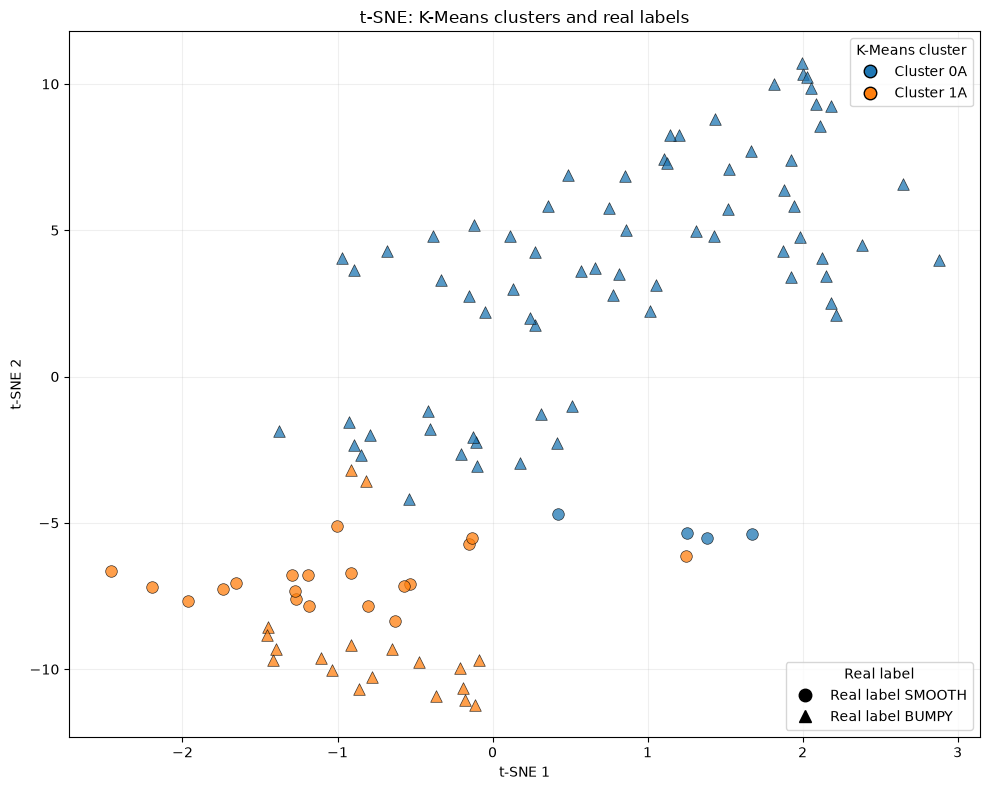

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt


# t-SNE visualization of K-Means clusters vs. real labels

print(f"\nRunning t-SNE on test data with shape: {X_test.shape}")

tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=RANDOM_STATE,
    init="pca",
    learning_rate="auto"
)

# applt t-sne transformation
X_test_tsne = tsne.fit_transform(X_test)


plt.figure(figsize=(10, 8))

# markers in order to represent real labels
markers = {
    0: "o",   # circle
    1: "^"    # triangle
}

# colors to represent the created clusters
colors = {
    0: "tab:blue",
    1: "tab:orange"
}

for cluster in range(N_CLUSTERS):
    for label in np.unique(y_test):
        mask = (test_clusters == cluster) & (y_test == label)

        if not np.any(mask):
            continue

        plt.scatter(
            X_test_tsne[mask, 0],
            X_test_tsne[mask, 1],
            c=colors[cluster],
            marker=markers[label],
            alpha=0.75,
            s=70,
            edgecolors="black",
            linewidths=0.5
        )


# create separate legends

# Legend for created clusters
cluster_handles = [
    plt.Line2D(
        [0], [0],
        marker="o",
        color="w",
        markerfacecolor=colors[c],
        markeredgecolor="black",
        markersize=9,
        label=f"Cluster {c}"
    )
    for c in range(N_CLUSTERS)
]

cluster_legend = plt.legend(
    handles=cluster_handles,
    title="K-Means cluster",
    loc="upper right"
)

plt.gca().add_artist(cluster_legend)


# legend for actual labels
label_handles = [
    plt.Line2D(
        [0], [0],
        marker=markers[label],
        color="black",
        linestyle="None",
        markersize=9,
        label=f"Real label {"BUMPY" if label == 1 else "SMOOTH"}"
    )
    for label in np.unique(y_test)
]

plt.legend(
    handles=label_handles,
    title="Real label",
    loc="lower right"
)


plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE: K-Means clusters and real labels")

plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

<br>

## Feature Normalization for the Final Model (Z-score)

### What we do
We now train the final model on **all** our recordings. Before training, each selected feature is rescaled with a z-score:

$$z = \frac{x - \mu}{\sigma}$$

where $\mu$ and $\sigma$ are the mean and the standard deviation of that feature, computed over **all the windows of the whole training dataset** (all recordings together). After this step every feature has mean 0 and standard deviation 1.

### Why we normalize
Our features live on very different scales. For example, `acc_x_energy` is in the tens, `spectral_flatness` lies between 0 and 1, and the gyroscope band energies are around $10^{-4}$. Models based on distances or weights (KNN, SVM, Logistic Regression, K-Means, GMM, Fuzzy C-Means, DBSCAN, Agglomerative) would otherwise be dominated by the features with the largest numbers, regardless of how informative they are. Tree-based models (Decision Tree, Random Forest) are not affected by the scale.

### Why at this point
This global normalization uses the statistics of the **entire** dataset, so it must come **after** feature selection are finished.
This is beacuse in ft selection we use a search algorithm that evaluates models on a subset of the training dataset (which itself is splitted into train and validation sets).

Now the evaluation is over, and no part of our data is used as a test set anymore. Fitting the scaler on all the training windows is therefore correct, and it gives the final model the most accurate estimate of $\mu$ and $\sigma$.

We compute $\mu$ and $\sigma$ over all windows together, not separately for each recording. Labels are assigned per recording, so the difference in vibration level between recordings is exactly the information that separates smooth from bumpy roads, and per-recording normalization would remove it.


### Why the on the whole training dataset

#### Normalization: per recording or over the whole training set?

A z-score can be computed in two ways:
- **per recording:** each recording is normalized with its own mean and standard deviation;
- **global:** all windows of the training set are normalized with the same mean and standard deviation.

We use the **global** normalization. The reason becomes clear if we look at what a feature value contains.

#### Two parts in every feature value

$$\text{rms of a window} = \underbrace{\text{mean level of its recording}}_{\text{between recordings}} + \underbrace{\text{deviation of the window from that level}}_{\text{within a recording}}$$

- The **mean level** separates a bumpy recording from a smooth one. Our labels are assigned per recording, so **this is where the class information is**.
- The **deviation** only says whether a window is rougher or smoother than the average of *its own* recording.

#### A numerical example (illustrative values)

rms of 4 windows from one bumpy and one smooth recording:

| recording | windows | mean |
|---|---|---|
| bumpy | 3.0 · 2.5 · **0.5** · 2.0 | 2.0 |
| smooth | 0.3 · 0.5 · 0.4 · 0.4 | 0.4 |

The value **0.5** in the bumpy recording is a smooth stretch inside a bumpy road. It is labelled *bumpy* but it is actually smooth: it is a **label-noise** window. This happens in our data, because a bumpy road is not bumpy for its entire length.

**Per-recording z-score**, subtracting the recording mean and dividing by the recording standard deviation:

| recording | normalized windows | mean |
|---|---|---|
| bumpy | +1.07 · +0.53 · **−1.60** · 0.00 | 0 |
| smooth | −1.41 · +1.41 · 0.00 · 0.00 | 0 |

What happens:
1. **The level disappears.** Both recordings now have mean 0, so the model can no longer see that one vibrates at 2.0 and the other at 0.4.
2. **The classes overlap completely.** A smooth window (+1.41) now looks rougher than a bumpy one (0.00).
3. **Only the deviation is left, and it points the wrong way.** The most extreme value in the bumpy recording (−1.60) is the mislabelled window. What remains says "this window is smoother than its recording": the information that *contradicts* the label in noisy windows, not the information that supports it.
4. **The noise of the smooth recording is amplified.** Its small fluctuations (0.3 to 0.5) have a tiny standard deviation, and dividing by it turns them into ±1.41, the same scale as real bumps.

Since the label is constant inside each recording and the deviation has mean 0 in every recording, the remaining values are by construction uncorrelated with the label.

**Global z-score**, using the same mean and standard deviation for all 8 windows:

| recording | normalized windows | mean |
|---|---|---|
| bumpy | +1.73 · +1.25 · **−0.67** · +0.77 | +0.77 |
| smooth | −0.87 · −0.67 · −0.77 · −0.77 | −0.77 |

The difference in level between the two recordings is preserved, so the classes stay separated. The noisy window (−0.67) now lies among the smooth values, which is where it physically belongs.

### Conclusion
The class signal lives **between** recordings, while label noise lives **within** recordings. Per-recording normalization keeps only the second and discards the first. For this reason we compute the z-score over **all windows of the training set**.



### Deployment
The fitted scaler is stored together with the final model. The external dataset (real time recordings) is transformed with these stored $\mu$ and $\sigma$, never with its own statistics, so that its windows are measured on the same scale the model was trained on.

In [ ]:
# Normalization script



# feature_set per unsupervised

# feature set per unsupervised






